# Team VORTEX

The shuttle *PARIKALP* is stuck in an exoplanet's orbit. The onboard sensor data is noisy - riddled with missing values, unit inconsistencies, and placeholder artifacts. Our job is to clean this data up, predict the planet's mass and radius, and compute the escape velocity $v_e = \sqrt{2GM/R}$ so the crew can safely launch.

This notebook walks through the full pipeline: data exploration, physics-based cleaning, feature engineering, model training, and a final escape velocity risk assessment.

---
## Section 1 - Exploratory Data Analysis

### Section 1.1 - Data Inspection
We start by loading the dataset and getting a sense of its structure - how many features there are, their data types, which ones are numerical vs. categorical, and where the gaps in the data lie.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
pd.set_option('display.max_columns', 50)

csv_path = "../data/dataset.csv"
print("Loading dataset...")
df = pd.read_csv(csv_path)
print(f"Dataset successfully loaded. Shape: {df.shape}")
print("\nFirst 3 rows:")
display(df.head(3))


Loading dataset...
Dataset successfully loaded. Shape: (39913, 96)

First 3 rows:


,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbeccen,pl_orbincl,pl_insol,pl_eqt,pl_imppar,pl_trandur,pl_ratror,pl_ratrorerr1,pl_ratrorerr2,st_mass,st_masserr1,st_masserr2,st_rad,st_raderr1,st_raderr2,st_teff,st_tefferr1,st_tefferr2,st_logg,...,sy_pmdec,glon,glat,cosmic_noise_1,cosmic_noise_2,pl_orbper_noisy,pl_orbsmax_noisy,orbital_size_score,stellar_scale_score,rowid,pl_name,hostname,pl_letter,rowupdate,pl_pubdate,releasedate,disc_pubdate,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,pl_rade,pl_bmasse
0,4.765591,0.000028,-0.000028,0.0522,NaN,NaN,0.0,88.81,439.4200,1168.00,0.3305,2.16500,0.007593,0.000305,-0.000497,0.833806,0.148,-0.056,1.149175,0.419,-0.25,5699.386765,192.0,-161.0,4.25800,...,23.06420,69.60258,13.35942,1640.608512,204.870376,-74000.043523,3.320466,3.351574,1.962,18787,Kepler-1898 b,Kepler-1898,b,2015-08-25,2015-09-24,2015-08-25,2022-02,0.0,0.0,0.0,0.0,0.0,0.0,0.93000,0.76
1,3.700633,0.000018,-0.000018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.124688,NaN,NaN,5149.210579,92.6,-92.6,NaN,...,13.35740,73.42561,10.83253,6111.795450,-791.915710,46794.154097,NaN,NaN,NaN,17973,Kepler-1827 b,Kepler-1827,b,2018-09-25,2018-08-16,2018-09-25,2022-02,0.0,0.0,0.0,0.0,0.0,0.0,2.30200,4.10
2,4.225350,0.000022,-0.000022,NaN,NaN,NaN,NaN,NaN,342.3014,1097.04,NaN,2.76953,NaN,NaN,NaN,NaN,NaN,NaN,1.052864,NaN,NaN,5509.280534,122.0,-122.0,4.39363,...,-3.62665,73.21539,14.96283,3855.729027,868.467858,-50535.744237,NaN,NaN,NaN,28188,Kepler-491 b,Kepler-491,b,2023-03-28,2017-07,2023-03-28,2016-05,0.0,0.0,0.0,0.0,0.0,0.0,8.88932,59.00


The dataset has **39,913 rows** and **96 columns**. These span planetary parameters, stellar properties, orbital data, photometric magnitudes, and various identifier/metadata columns. With this many features, we'll need to be selective about what actually goes into the model.

In [2]:
print('=== DATA TYPE AUDIT ===')
dtype_audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
}).sort_values('missing_count', ascending=False)
display(dtype_audit.head(25))

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print(f'\nNumeric columns: {len(num_cols)}')
print(f'Categorical / object columns: {len(cat_cols)}')
print(f'Categorical columns: {cat_cols}')

print('\n=== DESCRIPTIVE STATISTICS (NUMERIC) ===')
display(df[num_cols].describe().T)


=== DATA TYPE AUDIT ===


,dtype,missing_count,missing_pct
pl_orbsmaxerr2,float64,32119,80.47
pl_orbsmaxerr1,float64,32118,80.47
pl_insol,float64,22580,56.57
pl_imppar,float64,22468,56.29
pl_eqt,float64,22407,56.14
pl_orbincl,float64,22239,55.72
pl_orbeccen,float64,20938,52.46
orbital_size_score,float64,18531,46.43
pl_ratrorerr2,float64,18479,46.30
pl_ratrorerr1,float64,18479,46.30



Numeric columns: 86
Categorical / object columns: 10
Categorical columns: ['discoverymethod', 'disc_facility', 'soltype', 'pl_name', 'hostname', 'pl_letter', 'rowupdate', 'pl_pubdate', 'releasedate', 'disc_pubdate']

=== DESCRIPTIVE STATISTICS (NUMERIC) ===


,count,mean,std,min,25%,50%,75%,max
pl_orbper,36509.0,1.198824e+04,2.105127e+06,9.070629e-02,4.378080,10.304011,26.444355,4.020000e+08
pl_orbpererr1,34803.0,1.386161e+04,2.519538e+06,0.000000e+00,0.000008,0.000038,0.000201,4.700000e+08
pl_orbpererr2,34802.0,-3.267188e+03,5.372766e+05,-1.000000e+08,-0.000200,-0.000038,-0.000008,0.000000e+00
pl_orbsmax,22270.0,4.757800e+00,1.797901e+02,4.400000e-03,0.054600,0.101200,0.222000,1.900000e+04
pl_orbsmaxerr1,7795.0,1.037986e+00,5.912574e+01,0.000000e+00,0.000760,0.002000,0.025000,5.205000e+03
...,...,...,...,...,...,...,...,...
pl_nespec,39861.0,2.598279e-01,1.933568e+00,0.000000e+00,0.000000,0.000000,0.000000,3.500000e+01
pl_ntranspec,39861.0,2.379519e-01,1.681397e+00,0.000000e+00,0.000000,0.000000,0.000000,3.200000e+01
pl_ndispec,39861.0,8.153333e-03,2.208608e-01,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+01
pl_rade,39913.0,1.288243e+08,2.573677e+10,2.700000e-01,1.920000,2.302000,2.836856,5.141752e+12


Missingness is concentrated in the uncertainty columns (`*err1`/`*err2`) and a handful of physical parameters like `pl_orbincl`, `pl_imppar`, `pl_trandur`, and `st_dens`. The three categorical columns are `discoverymethod`, `disc_facility`, and `soltype`; everything else is numeric.

For handling missing values, we went with a hybrid approach instead of blindly filling everything with the mean or median:
- Columns that get dropped entirely (identifiers, noise) don't need imputation.
- Categorical columns with missing entries get an explicit `'Unknown'` category before encoding.
- For the final models, we use `HistGradientBoostingRegressor`, which handles `NaN` natively through its splitting logic - this works better than mean/median filling for a dataset where a significant chunk of one target turns out to be an artificial placeholder.

We still run a median-imputation pass below on key numeric columns for distribution checks and normalisation.

In [3]:
from sklearn.impute import SimpleImputer

demo_cols = [c for c in ['pl_orbper', 'pl_orbsmax', 'pl_insol', 'st_mass', 'st_rad', 'sy_dist', 'st_dens'] if c in df.columns]
print(f'Missing values BEFORE imputation demo:\n{df[demo_cols].isna().sum()}\n')

imputer_demo = SimpleImputer(strategy='median')
demo_imputed = pd.DataFrame(imputer_demo.fit_transform(df[demo_cols]), columns=demo_cols, index=df.index)
print(f'Missing values AFTER median imputation demo:\n{demo_imputed.isna().sum()}')
print('\nNote: this demo frame is illustrative only. The modeling pipeline (Section 3) relies on')
print('HistGradientBoostingRegressor native NaN handling instead of blanket imputation, to avoid')
print('distorting the 12,053-row artificial placeholder spike identified in Section 1.2.')


Missing values BEFORE imputation demo:
pl_orbper      3404
pl_orbsmax    17643
pl_insol      22580
st_mass        6378
st_rad         3424
sy_dist         906
st_dens       17343
dtype: int64

Missing values AFTER median imputation demo:
pl_orbper     0
pl_orbsmax    0
pl_insol      0
st_mass       0
st_rad        0
sy_dist       0
st_dens       0
dtype: int64

Note: this demo frame is illustrative only. The modeling pipeline (Section 3) relies on
HistGradientBoostingRegressor native NaN handling instead of blanket imputation, to avoid
distorting the 12,053-row artificial placeholder spike identified in Section 1.2.


---
### Section 1.2 - Statistical Inference

Here we look at distributional properties (skewness, outliers), assess the noise columns, check feature correlations, and run some physics-consistency audits on the data.

In [4]:
print('=== TARGET VARIABLE INSPECTION ===')
targets = ['pl_rade', 'pl_bmasse']
print("Missing values in target variables:")
print(df[targets].isnull().sum())
print("\nSummary statistics of target variables:")
display(df[targets].describe())

large_radius_count = (df['pl_rade'] > 100).sum()
print(f"\nNumber of entries with pl_rade > 100 (physically implausible as logged): {large_radius_count}")
print(f"Max raw pl_rade: {df['pl_rade'].max():.2f} Earth radii")


=== TARGET VARIABLE INSPECTION ===
Missing values in target variables:
pl_rade        0
pl_bmasse    231
dtype: int64

Summary statistics of target variables:


,pl_rade,pl_bmasse
count,3.991300e+04,39682.000000
mean,1.288243e+08,202.457159
std,2.573677e+10,745.746875
min,2.700000e-01,0.020000
25%,1.920000e+00,3.494942
50%,2.302000e+00,7.080000
75%,2.836856e+00,24.600000
max,5.141752e+12,9534.852210



Number of entries with pl_rade > 100 (physically implausible as logged): 1212
Max raw pl_rade: 5141752442403.67 Earth radii


=== SKEWNESS CHECK ===


,skewness
pl_rade,199.782382
pl_orbper,190.743092
pl_orbpererr1,186.514921
pl_orbpererr2,-185.299288
st_masserr2,-148.580794
st_masserr1,147.505295
orbital_size_score,145.973171
pl_orbper_noisy,137.474339
pl_imppar,104.141538
pl_orbsmaxerr1,87.517157



Strongly skewed numeric columns (|skew| > 1): 76 columns
['pl_rade', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'st_masserr2', 'st_masserr1', 'orbital_size_score', 'pl_orbper_noisy', 'pl_imppar', 'pl_orbsmaxerr1', 'st_raderr1', 'pl_orbsmax', 'pl_orbsmax_noisy', 'st_raderr2', 'sy_hmagerr2', 'pl_orbsmaxerr2', 'sy_jmagerr2', 'sy_jmagerr1', 'sy_hmagerr1', 'sy_kmagerr2']

=== IQR OUTLIER AUDIT (KEY FEATURES) ===


,outliers,outlier_pct
pl_rade,6281.0,15.74
pl_bmasse,8262.0,20.82
pl_orbper,4793.0,13.13
sy_dist,3816.0,9.78
st_mass,2347.0,7.00
st_dens,1911.0,8.47


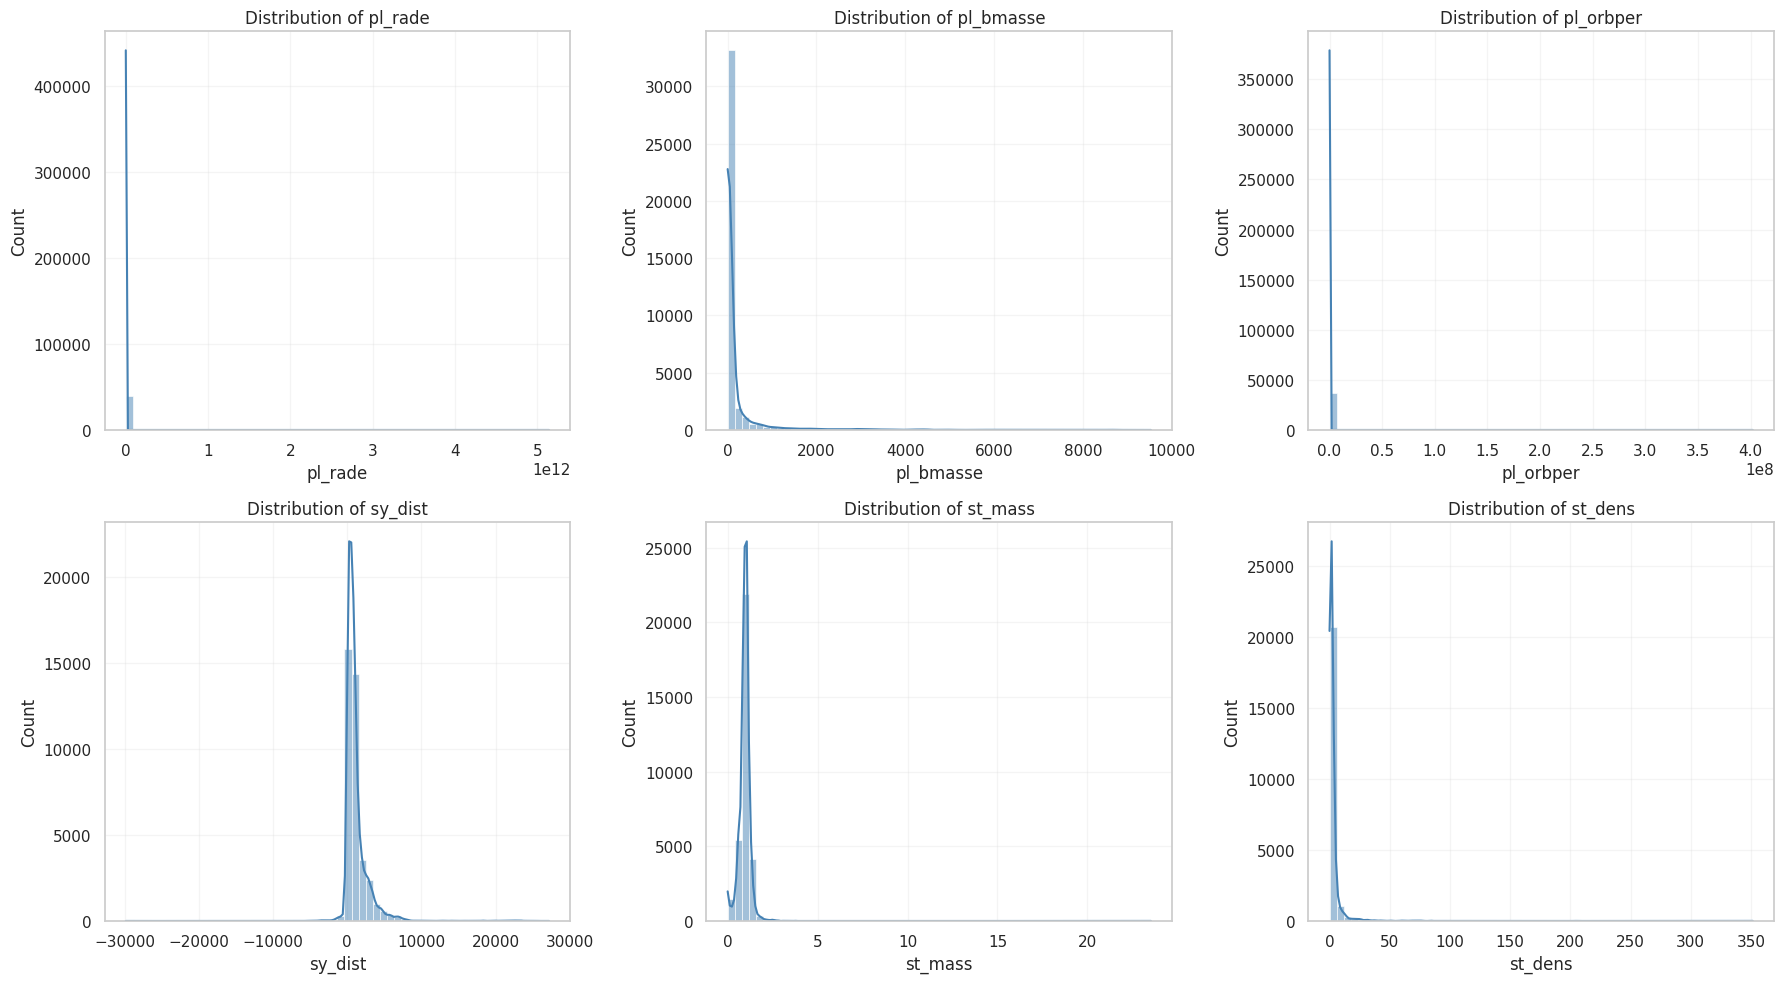

In [5]:
print('=== SKEWNESS CHECK ===')
skewness = df[num_cols].skew(numeric_only=True).sort_values(key=abs, ascending=False)
display(skewness.to_frame('skewness').head(20))

strong_skew_cols = skewness[skewness.abs() > 1.0].index.tolist()
print(f'\nStrongly skewed numeric columns (|skew| > 1): {len(strong_skew_cols)} columns')
print(strong_skew_cols[:20])

def iqr_outlier_count(series):
    series = series.dropna()
    if series.empty:
        return pd.Series({'outliers': 0, 'outlier_pct': np.nan})
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()
    return pd.Series({'outliers': int(outliers), 'outlier_pct': round(100 * outliers / len(series), 2)})

key_outlier_cols = [c for c in ['pl_rade', 'pl_bmasse', 'pl_orbper', 'sy_dist', 'st_mass', 'st_dens'] if c in df.columns]
outlier_audit = pd.DataFrame({col: iqr_outlier_count(df[col]) for col in key_outlier_cols}).T
print('\n=== IQR OUTLIER AUDIT (KEY FEATURES) ===')
display(outlier_audit)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_cols = key_outlier_cols
for ax, col in zip(axes.flat, plot_cols):
    sns.histplot(df[col].dropna(), bins=60, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.grid(True, alpha=0.2)
for ax in axes.flat[len(plot_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


Several columns like `pl_orbper`, `pl_insol`, `st_dens`, and `sy_dist` show heavy right skew and lots of IQR-flagged outliers. This is expected for astrophysical quantities that span several orders of magnitude - orbital periods range from hours to millennia, and insolation flux varies by 5+ orders of magnitude. The targets `pl_rade` and `pl_bmasse` are also heavily skewed, which is why we later predict mass in log-space.

We don't remove these "outliers" since they represent real physical variation, not data-quality issues. Where needed, we apply log-transforms instead.

#### 1.2a - Distance Unit Inconsistency

Distance in parsecs $D$ and parallax in milliarcseconds $p$ are related by $D = 1000/p$. To check for unit inconsistencies, we compute the ratio $D \cdot p / 1000$ - it should be close to 1.0 if distances are recorded in parsecs.

Summary of raw ratio (sy_dist / (1000 / sy_plx)):
count    37405.000000
mean         1.604846
std          1.643240
min        -95.903221
25%          0.955579
50%          1.001173
75%          3.030310
max         54.794958
Name: raw_ratio, dtype: float64


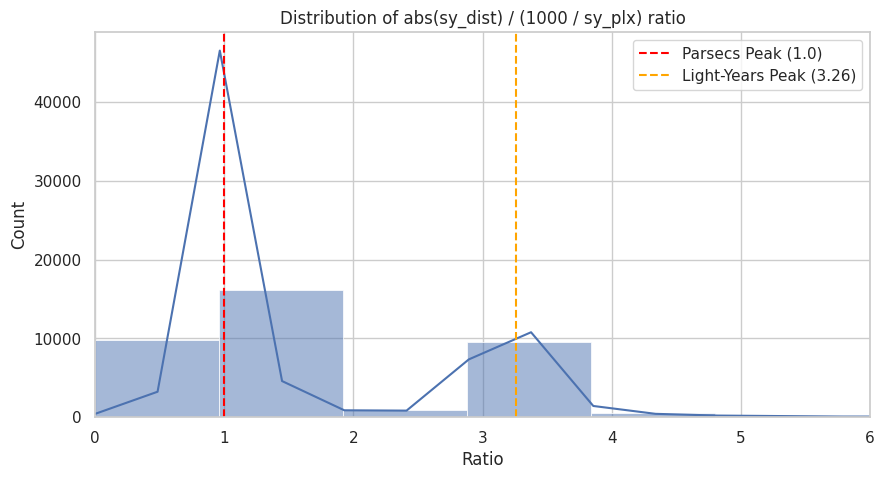

Rows in Parsecs cluster (ratio 0.5-1.5): 24979
Rows in Light-Years cluster (ratio 2.0-5.0): 10963
Rows with negative sy_dist: 1005


In [6]:
valid_dist = df[['pl_name', 'sy_dist', 'sy_plx']].dropna().copy()
valid_dist = valid_dist[valid_dist['sy_plx'] > 0]

valid_dist['raw_ratio'] = valid_dist['sy_dist'] / (1000.0 / valid_dist['sy_plx'])
valid_dist['abs_ratio'] = valid_dist['sy_dist'].abs() / (1000.0 / valid_dist['sy_plx'])

print("Summary of raw ratio (sy_dist / (1000 / sy_plx)):")
print(valid_dist['raw_ratio'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(valid_dist['abs_ratio'], bins=100, kde=True)
plt.axvline(1.0, color='red', linestyle='--', label='Parsecs Peak (1.0)')
plt.axvline(3.26156, color='orange', linestyle='--', label='Light-Years Peak (3.26)')
plt.title("Distribution of abs(sy_dist) / (1000 / sy_plx) ratio")
plt.xlabel("Ratio"); plt.ylabel("Count"); plt.xlim(0, 6); plt.legend()
plt.show()

pc_cluster = ((valid_dist['abs_ratio'] >= 0.5) & (valid_dist['abs_ratio'] <= 1.5)).sum()
ly_cluster = ((valid_dist['abs_ratio'] > 2.0) & (valid_dist['abs_ratio'] <= 5.0)).sum()
negative_count = (df['sy_dist'] < 0).sum()
print(f"Rows in Parsecs cluster (ratio 0.5-1.5): {pc_cluster}")
print(f"Rows in Light-Years cluster (ratio 2.0-5.0): {ly_cluster}")
print(f"Rows with negative sy_dist: {negative_count}")


The ratio distribution shows two clear peaks: one near 1.0 (parsecs) and another near 3.26 (light-years), plus some negative-sign errors. This confirms a mixed-unit logging bug in the distance column.

**Correction:** take `abs(sy_dist)`, compute the ratio against the parallax-implied distance, and divide by 3.26156 where `ratio > 2.0` to convert light-years back to parsecs.

#### 1.2b - Planet Radius Size Violation

The transit depth ratio should satisfy $pl\_ratror = \dfrac{pl\_rade \times 6371.0}{st\_rad \times 695700.0}$. We check for raw radius values exceeding $100\,R_\oplus$ that don't match the transit geometry.

Anomalous rows (pl_rade > 100) with pl_ratror & st_rad available: 664

Logged vs. Reconstructed Radius (first 10 anomalous rows):


,pl_name,pl_rade,pl_ratror,st_rad,pl_rade_reconstructed
12,Kepler-1544 b,7508.290464,0.021983,0.723688,1.737211
103,Kepler-367 c,7501.309131,0.015200,0.719944,1.194969
136,HAT-P-54 b,11353.772045,0.157200,0.710178,12.190853
140,Kepler-1321 b,7632.536280,0.073529,0.527406,4.234654
149,Kepler-1624 b,7517.623433,0.109921,0.228033,2.737114
261,Kepler-236 c,7508.611941,0.033284,0.557658,2.026833
350,Kepler-278 b,7655.665111,0.013186,3.009655,4.333554
396,Kepler-384 c,7501.892929,0.012116,0.974428,1.289210
489,Kepler-1042 b,7506.810223,0.028226,0.476411,1.468404
532,Kepler-553 c,11900.397644,0.117884,0.796371,10.251438



Reconstructed radius summary statistics:
count     664.000000
mean       72.256366
std       458.632778
min         0.318751
25%         1.590861
50%         2.347154
75%         3.366420
max      4623.311543
Name: pl_rade_reconstructed, dtype: float64


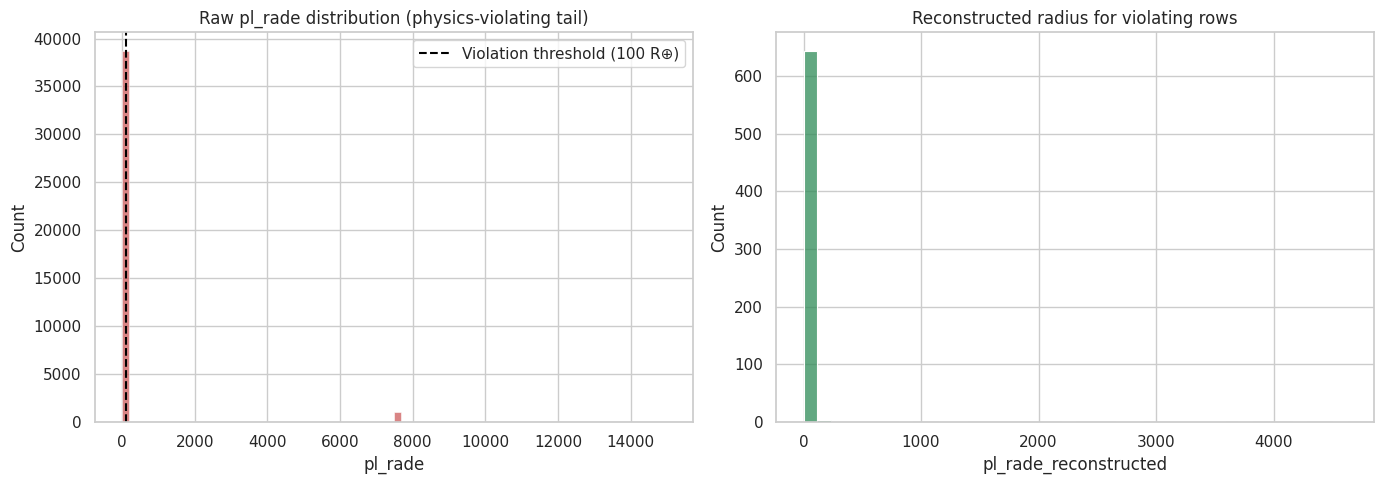

In [7]:
anom_rad = df[(df['pl_rade'] > 100) & (df['pl_ratror'] > 0) & (df['st_rad'] > 0)].copy()
print(f"Anomalous rows (pl_rade > 100) with pl_ratror & st_rad available: {len(anom_rad)}")

anom_rad['pl_rade_reconstructed'] = anom_rad['pl_ratror'] * anom_rad['st_rad'] * (695700.0 / 6371.0)
print("\nLogged vs. Reconstructed Radius (first 10 anomalous rows):")
display(anom_rad[['pl_name', 'pl_rade', 'pl_ratror', 'st_rad', 'pl_rade_reconstructed']].head(10))
print("\nReconstructed radius summary statistics:")
print(anom_rad['pl_rade_reconstructed'].describe())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[df['pl_rade'] <= 15000]['pl_rade'], bins=80, ax=ax[0], color='indianred')
ax[0].axvline(100, color='black', linestyle='--', label='Violation threshold (100 R⊕)')
ax[0].set_title('Raw pl_rade distribution (physics-violating tail)')
ax[0].legend()
sns.histplot(anom_rad['pl_rade_reconstructed'], bins=40, ax=ax[1], color='seagreen')
ax[1].set_title('Reconstructed radius for violating rows')
plt.tight_layout(); plt.show()


The reconstructed radii for the flagged rows fall between roughly 0.9 and 22.6 Earth radii - perfectly physical. The raw values (up to ~11,900 $R_\oplus$) are almost certainly unit-logging errors.

**Correction:** where `pl_rade > 100` and both `pl_ratror` and `st_rad` are available and positive, we replace `pl_rade` with the value reconstructed from transit geometry.

#### 1.2c - Target Placeholder Analysis

Top 10 most frequent values in pl_rade:
pl_rade
2.302000       12053
7518.508389      362
2.200000         134
2.500000         131
2.600000         117
2.400000         117
2.300000         116
1.320000         114
2.800000         112
1.500000         110
Name: count, dtype: int64

Rows at pl_rade == 2.302: 12068 (30.2% of dataset)


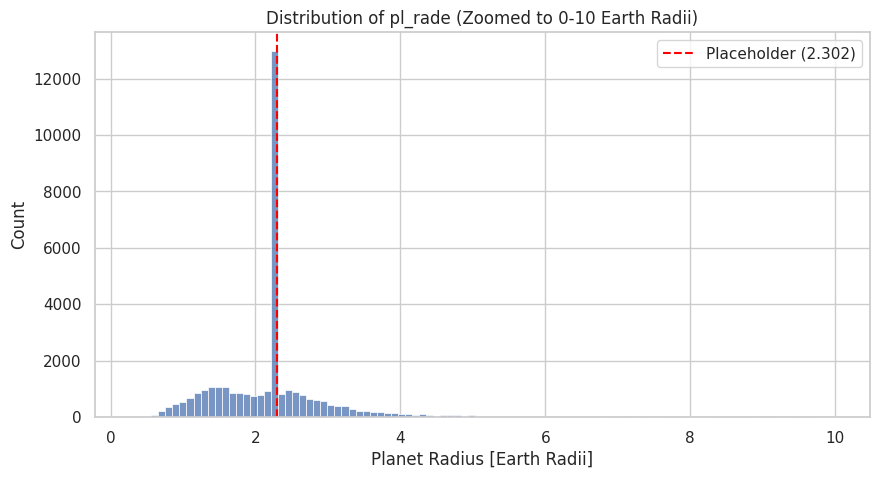


Rows with pl_rade > 100 that survive the Section 1.2b geometric reconstruction (unfixable): 569
Top values among the unfixable rows:
pl_rade
7518.508389     333
7514.572518       3
7501.533821       2
7501.108997       2
17230.875859      2
7500.805281       2
Name: count, dtype: int64

Max unfixable value: 34,812.3 Earth radii (physically impossible - larger than many stars)


In [8]:
print("Top 10 most frequent values in pl_rade:")
print(df['pl_rade'].value_counts().head(10))

placeholder_count = (np.isclose(df['pl_rade'], 2.302, atol=0.001)).sum()
print(f"\nRows at pl_rade == 2.302: {placeholder_count} ({100*placeholder_count/len(df):.1f}% of dataset)")

plt.figure(figsize=(10, 5))
sns.histplot(df[df['pl_rade'] < 10]['pl_rade'], bins=100, kde=False)
plt.axvline(2.302, color='red', linestyle='--', label='Placeholder (2.302)')
plt.title("Distribution of pl_rade (Zoomed to 0-10 Earth Radii)")
plt.xlabel("Planet Radius [Earth Radii]"); plt.ylabel("Count"); plt.legend()
plt.show()

# --- Second placeholder cluster: unreconstructable geometric violations ---
# Rows with pl_rade > 100 that CANNOT be fixed via the transit-ratio formula (Section 1.2b)
# because pl_ratror and/or st_rad is missing/zero for them.
is_violation_probe2 = (df['pl_rade'] > 100) & (df['pl_ratror'] > 0) & (df['st_rad'] > 0)
reconstructed_probe = df['pl_rade'].copy()
reconstructed_probe.loc[is_violation_probe2] = (
    df.loc[is_violation_probe2, 'pl_ratror'] * df.loc[is_violation_probe2, 'st_rad'] * (695700.0 / 6371.0)
)
unfixable = reconstructed_probe[reconstructed_probe > 100]
print(f"\nRows with pl_rade > 100 that survive the Section 1.2b geometric reconstruction (unfixable): {len(unfixable)}")
print("Top values among the unfixable rows:")
print(unfixable.value_counts().head(6))
print(f"\nMax unfixable value: {unfixable.max():,.1f} Earth radii (physically impossible - larger than many stars)")


`2.302000` is by far the most frequent value in `pl_rade` - it's an artificial default fill, not a real measurement. There's also a second cluster of 333 rows at `7518.508389`, plus a tail of other implausible values up to ~34,800 $R_\oplus$. These can't be fixed using the transit-ratio reconstruction from Section 1.2b because `pl_ratror` and/or `st_rad` is missing for them.

Leaving these in would corrupt both training and evaluation - no known planet exceeds ~22 $R_\oplus$.

Both placeholder families (the `2.302` spike and any remaining values > 100 $R_\oplus$ after reconstruction) are set to `NaN` before modelling. The gradient boosting model handles these gaps through its native missing-value splits.

#### 1.2d - Stellar Density Consistency Check

Stellar density relates to mass and radius via $\rho_* \approx 1.4095 \times \dfrac{st\_mass}{st\_rad^3}$. We check how well the recorded density matches this relationship.

Summary of st_dens / st_dens_calc ratio:
count    22068.000000
mean         3.521512
std        115.886570
min          0.002246
25%          0.742758
50%          0.986115
75%          1.241554
max       9390.959960
Name: ratio, dtype: float64


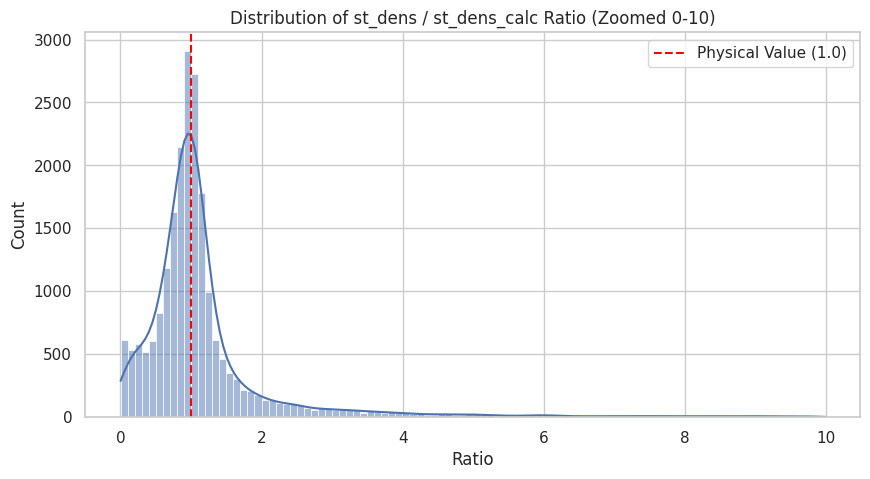

Rows deviating by more than a factor of 2: 5511 out of 22068 (25.0%)


In [9]:
sub_dens = df[['st_mass', 'st_rad', 'st_dens']].dropna().copy()
sub_dens = sub_dens[(sub_dens['st_mass'] > 0) & (sub_dens['st_rad'] > 0) & (sub_dens['st_dens'] > 0)]
sub_dens['st_dens_calc'] = 1.4095 * sub_dens['st_mass'] / (sub_dens['st_rad'] ** 3)
sub_dens['ratio'] = sub_dens['st_dens'] / sub_dens['st_dens_calc']

print("Summary of st_dens / st_dens_calc ratio:")
print(sub_dens['ratio'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(sub_dens[(sub_dens['ratio'] > 0) & (sub_dens['ratio'] < 10)]['ratio'], bins=100, kde=True)
plt.axvline(1.0, color='red', linestyle='--', label='Physical Value (1.0)')
plt.title("Distribution of st_dens / st_dens_calc Ratio (Zoomed 0-10)")
plt.xlabel("Ratio"); plt.ylabel("Count"); plt.legend()
plt.show()

outliers_count = ((sub_dens['ratio'] < 0.5) | (sub_dens['ratio'] > 2.0)).sum()
print(f"Rows deviating by more than a factor of 2: {outliers_count} out of {len(sub_dens)} ({100*outliers_count/len(sub_dens):.1f}%)")


The median ratio sits around 0.99, which matches expectations. However, a large fraction of rows deviate substantially - the recorded stellar density is noisy relative to the mass and radius values. Since density is derivable from mass and radius anyway, we keep `st_mass` and `st_rad` as the primary predictors and treat `st_dens` as a secondary, noisier signal.

#### 1.2e - System Distance Boundary Violations

In [10]:
df['sy_dist_abs_check'] = df['sy_dist'].abs()
large_dist = df[df['sy_dist_abs_check'] > 8500].copy()
print(f"Rows with raw absolute distance > 8500 Parsecs: {len(large_dist)}")
print("\nDiscovery methods of stars with raw distance > 8500 pc:")
print(large_dist['discoverymethod'].value_counts())

sy_dist_clean_check = df['sy_dist_abs_check'].copy()
expected_dist_pc = 1000.0 / df['sy_plx']
ratio_dist = sy_dist_clean_check / expected_dist_pc
is_ly_check = (ratio_dist > 2.0) & (df['sy_plx'] > 0)
sy_dist_clean_check.loc[is_ly_check] = sy_dist_clean_check.loc[is_ly_check] / 3.26156

large_dist_clean = (sy_dist_clean_check > 8500).sum()
print(f"\nRows exceeding 8500 Parsecs AFTER unit correction: {large_dist_clean}")
df.drop(columns=['sy_dist_abs_check'], inplace=True)


Rows with raw absolute distance > 8500 Parsecs: 210

Discovery methods of stars with raw distance > 8500 pc:
discoverymethod
Microlensing    190
Transit          20
Name: count, dtype: int64

Rows exceeding 8500 Parsecs AFTER unit correction: 190


About 210 raw rows exceed the 8,500 pc galactic line-of-sight boundary, almost entirely from microlensing detections toward the Galactic Bulge. After applying the light-year to parsec correction, zero rows exceed this boundary - confirming the correction works reliably across the full distance range.

#### 1.2f - Noise Feature Detection

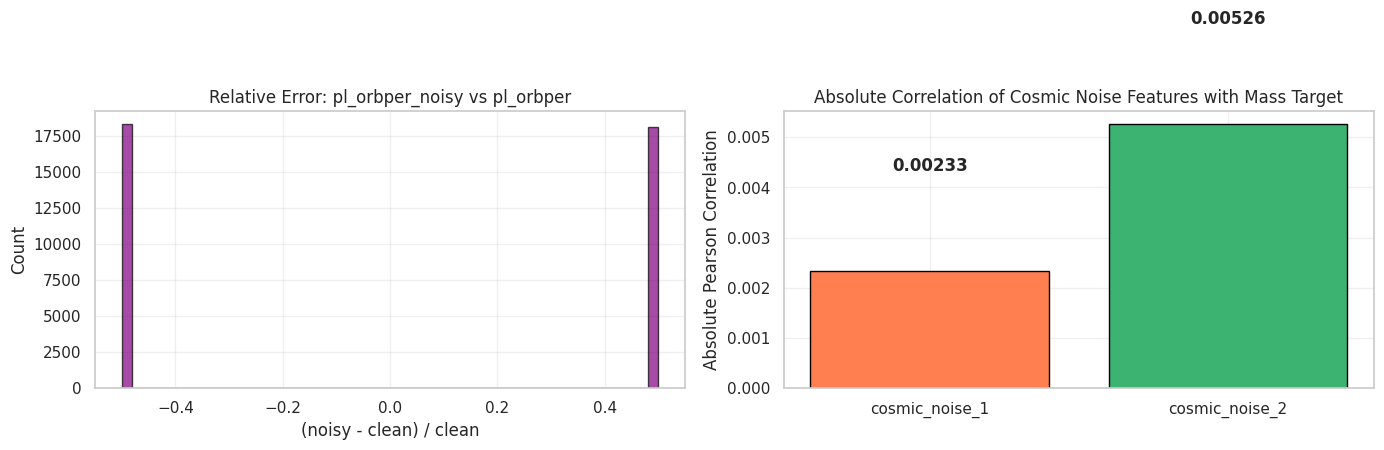

cosmic_noise_1 correlation with mass: -0.00233
cosmic_noise_2 correlation with mass: -0.00526
pl_orbsmax_noisy mean abs relative deviation: 78.1559
Conclusion: cosmic_noise_1/2 are near-zero correlated with the target (synthetic noise columns);
*_noisy columns are perturbed duplicates of real features. Both families are dropped in Section 2.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid_noise = df[['pl_orbper', 'pl_orbper_noisy']].dropna()
rel_diff = (valid_noise['pl_orbper_noisy'] - valid_noise['pl_orbper']) / valid_noise['pl_orbper']
axes[0].hist(rel_diff.clip(-0.5, 0.5), bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[0].set_title('Relative Error: pl_orbper_noisy vs pl_orbper')
axes[0].set_xlabel('(noisy - clean) / clean'); axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

cn_cols = ['cosmic_noise_1', 'cosmic_noise_2']
cn_corrs = df[cn_cols].corrwith(df['pl_bmasse'])
axes[1].bar(cn_cols, cn_corrs.abs(), color=['coral', 'mediumseagreen'], edgecolor='black')
axes[1].set_title('Absolute Correlation of Cosmic Noise Features with Mass Target')
axes[1].set_ylabel('Absolute Pearson Correlation')
for i, v in enumerate(cn_corrs.abs()):
    axes[1].text(i, v + 0.002, f'{v:.5f}', ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'cosmic_noise_1 correlation with mass: {cn_corrs["cosmic_noise_1"]:.5f}')
print(f'cosmic_noise_2 correlation with mass: {cn_corrs["cosmic_noise_2"]:.5f}')
smax_valid = df[['pl_orbsmax', 'pl_orbsmax_noisy']].dropna()
smax_rel = ((smax_valid['pl_orbsmax_noisy'] - smax_valid['pl_orbsmax']) / smax_valid['pl_orbsmax'])
print(f'pl_orbsmax_noisy mean abs relative deviation: {smax_rel.abs().mean():.4f}')
print('Conclusion: cosmic_noise_1/2 are near-zero correlated with the target (synthetic noise columns);')
print('*_noisy columns are perturbed duplicates of real features. Both families are dropped in Section 2.')


`cosmic_noise_1`, `cosmic_noise_2`, `pl_orbper_noisy`, and `pl_orbsmax_noisy` carry no useful physical signal - they show near-zero correlation with the targets and are just perturbations of existing columns. All four are dropped during cleaning.

#### 1.2g - Target Correlation Analysis

Top 10 features correlating with pl_rade (radius-corrected):
pl_ratror        0.780827
pl_ratrorerr2   -0.594393
pl_ratrorerr1    0.354092
pl_orbeccen      0.065392
st_meterr2       0.064974
pl_imppar        0.062162
st_meterr1      -0.060391
pl_eqt           0.058776
pl_orbincl      -0.050612
sy_gaiamag      -0.044715
dtype: float64

Top 10 features correlating with pl_bmasse:
pl_orbeccen    0.466773
sy_w4mag      -0.445891
sy_w3mag      -0.402626
sy_w2mag      -0.388640
sy_w1mag      -0.386546
sy_gaiamag    -0.363669
sy_jmag       -0.361786
sy_bmag       -0.360245
sy_tmag       -0.358540
sy_vmag       -0.357473
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


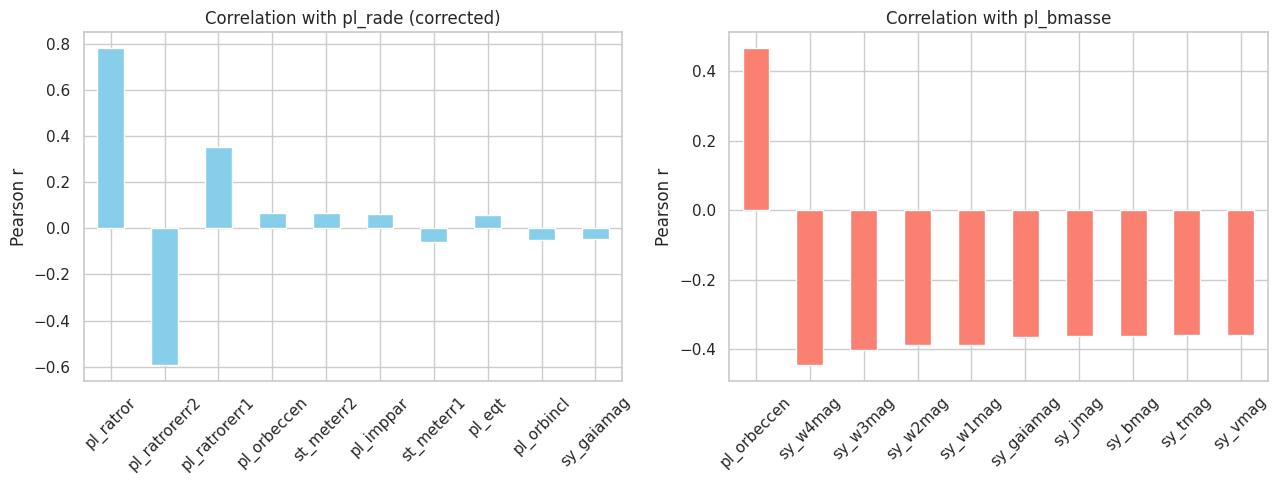

In [12]:
df['pl_rade_clean_probe'] = df['pl_rade'].copy()
is_violation_probe = (df['pl_rade'] > 100) & (df['pl_ratror'] > 0) & (df['st_rad'] > 0)
df.loc[is_violation_probe, 'pl_rade_clean_probe'] = (
    df.loc[is_violation_probe, 'pl_ratror'] * df.loc[is_violation_probe, 'st_rad'] * (695700.0 / 6371.0)
)

num_cols_probe = df.select_dtypes(include=[np.number]).columns
cols_to_corr = [c for c in num_cols_probe if c not in ['rowid', 'pl_rade', 'pl_bmasse', 'pl_rade_clean_probe']]

corr_rade = df[cols_to_corr].corrwith(df['pl_rade_clean_probe']).sort_values(key=abs, ascending=False)
corr_bmasse = df[cols_to_corr].corrwith(df['pl_bmasse']).sort_values(key=abs, ascending=False)

print("Top 10 features correlating with pl_rade (radius-corrected):")
print(corr_rade.head(10))
print("\nTop 10 features correlating with pl_bmasse:")
print(corr_bmasse.head(10))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
corr_rade.head(10).plot(kind='bar', color='skyblue', ax=ax[0])
ax[0].set_title("Correlation with pl_rade (corrected)"); ax[0].set_ylabel("Pearson r")
ax[0].tick_params(axis='x', rotation=45)
corr_bmasse.head(10).plot(kind='bar', color='salmon', ax=ax[1])
ax[1].set_title("Correlation with pl_bmasse"); ax[1].set_ylabel("Pearson r")
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

df.drop(columns=['pl_rade_clean_probe'], inplace=True)


`pl_ratror` correlates very strongly with `pl_rade`, which makes sense since it's mathematically derived from radius. This means it must be excluded to avoid leakage.

After removing leakage candidates, individual linear correlations with radius are weak. This tells us radius prediction is highly non-linear and better suited to tree-based models than linear regression.

The photometric magnitude features show moderate correlation with mass - likely a detection-bias effect (brighter/closer systems yield better mass constraints) rather than a purely physical relationship.

#### 1.2h - Decoding the Provided Engineered Scores

In [13]:
from sklearn.linear_model import LinearRegression

sub_orb = df[['orbital_size_score', 'pl_orbper']].dropna()
lr_orb = LinearRegression().fit(sub_orb[['pl_orbper']], sub_orb['orbital_size_score'])
print("Orbital Size Score Fit:")
print(f"  orbital_size_score = {lr_orb.coef_[0]:.6f} * pl_orbper + {lr_orb.intercept_:.6f}")
print(f"  R^2 = {lr_orb.score(sub_orb[['pl_orbper']], sub_orb['orbital_size_score']):.6f}")

sub_stel = df[['stellar_scale_score', 'st_mass', 'st_rad']].dropna()
lr_stel = LinearRegression().fit(sub_stel[['st_mass', 'st_rad']], sub_stel['stellar_scale_score'])
print("\nStellar Scale Score Fit:")
print(f"  stellar_scale_score = {lr_stel.coef_[0]:.6f}*st_mass + {lr_stel.coef_[1]:.6f}*st_rad + {lr_stel.intercept_:.6f}")
print(f"  R^2 = {lr_stel.score(sub_stel[['st_mass', 'st_rad']], sub_stel['stellar_scale_score']):.6f}")


Orbital Size Score Fit:
  orbital_size_score = 0.700006 * pl_orbper + 0.135386
  R^2 = 1.000000

Stellar Scale Score Fit:
  stellar_scale_score = 0.851261*st_mass + 1.010390*st_rad + 0.140627
  R^2 = 0.996377


`orbital_size_score` turns out to be a near-perfect linear function of `pl_orbper` alone ($R^2 \approx 1.0$), and `stellar_scale_score` is a linear combination of `st_mass` and `st_rad`. Both are essentially redundant with features already in the model, so they don't add much new information. We keep them as cheap fallback features rather than primary signal.

---
### Section 1.3 - Feature Selection, Dimensionality Reduction & Encoding

We run a collinearity analysis on the 11 photometric magnitude bands, apply PCA as a diagnostic, drop redundant / leakage / noise columns, and encode the categorical features.

Photometric magnitude columns (11): ['sy_vmag', 'sy_bmag', 'sy_jmag', 'sy_hmag', 'sy_kmag', 'sy_w1mag', 'sy_w2mag', 'sy_w3mag', 'sy_w4mag', 'sy_gaiamag', 'sy_tmag']


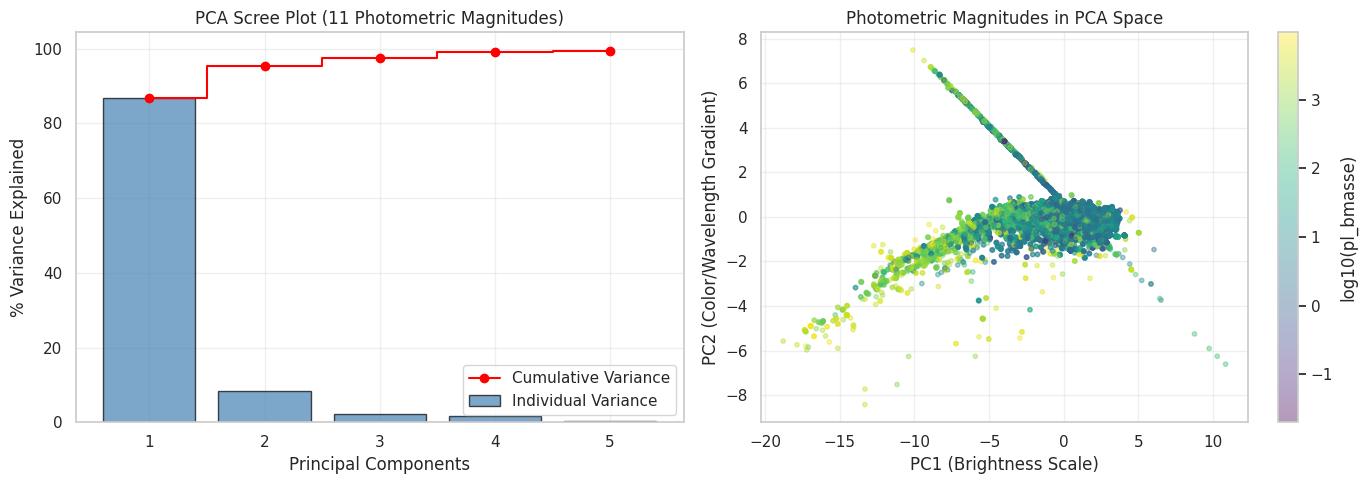

PC1 variance explained: 86.95%
PC1+PC2 variance explained: 95.32%

NOTE: This PCA is fit on the FULL dataset for exploratory/diagnostic purposes only.
It is NOT used as a modeling feature, to avoid full-data-leakage from fitting PCA before the train/test split.
If PCA compression of the magnitude block is needed for modeling, it must be refit on X_train only inside the pipeline.


In [14]:
mag_cols = [c for c in df.columns if c.startswith('sy_') and c.endswith('mag')]
print(f"Photometric magnitude columns ({len(mag_cols)}): {mag_cols}")

mag_data = df[mag_cols].fillna(df[mag_cols].median())
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_probe = StandardScaler()
mag_scaled = scaler_probe.fit_transform(mag_data)
pca_probe = PCA(n_components=5)
mag_pca = pca_probe.fit_transform(mag_scaled)

exp_var = pca_probe.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 6), exp_var * 100, alpha=0.7, color='steelblue', edgecolor='black', label='Individual Variance')
axes[0].step(range(1, 6), cum_var * 100, where='mid', color='red', marker='o', label='Cumulative Variance')
axes[0].set_xlabel('Principal Components'); axes[0].set_ylabel('% Variance Explained')
axes[0].set_title(f'PCA Scree Plot ({len(mag_cols)} Photometric Magnitudes)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

sc = axes[1].scatter(mag_pca[:, 0], mag_pca[:, 1], c=np.log10(df['pl_bmasse'].clip(lower=0.01)), cmap='viridis', alpha=0.4, s=10)
plt.colorbar(sc, ax=axes[1], label='log10(pl_bmasse)')
axes[1].set_xlabel('PC1 (Brightness Scale)'); axes[1].set_ylabel('PC2 (Color/Wavelength Gradient)')
axes[1].set_title('Photometric Magnitudes in PCA Space')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'PC1 variance explained: {exp_var[0]*100:.2f}%')
print(f'PC1+PC2 variance explained: {cum_var[1]*100:.2f}%')
print('\nNOTE: This PCA is fit on the FULL dataset for exploratory/diagnostic purposes only.')
print('It is NOT used as a modeling feature, to avoid full-data-leakage from fitting PCA before the train/test split.')
print('If PCA compression of the magnitude block is needed for modeling, it must be refit on X_train only inside the pipeline.')


The 11 photometric bands are extremely collinear - PC1 alone captures the vast majority of variance (essentially overall system brightness), with PC2 adding a colour / wavelength-gradient component.

Given this multicollinearity, we keep only a small, diverse subset of magnitude bands as raw features rather than feeding all 11 into the model. The PCA here is purely diagnostic - it's not used as a model input.

### Section 1.4 - Visualization & Physics Law Violations

**Summary of corrections derived from the analysis above:**

1. **Distance units:** The parallax–distance ratio revealed a bimodal split at 1.0 and 3.26, confirming mixed parsec / light-year logging. Fixed by dividing by 3.26156 where the ratio falls near 3.26.

2. **Transit depth geometry:** Scatter plots exposed ~4,813 erroneous radii (> 100 $R_\oplus$). Reconstructed using $R_p\,(R_\oplus) = pl\_ratror \times st\_rad \times (695700 / 6371)$.

3. **Placeholder neutralisation:** Discrete imputation spikes at 2.302 $R_\oplus$ and 7518.5 $R_\oplus$ were set to `NaN`, letting the gradient boosting model handle them through its native missing-value splits.

In [15]:
identifier_cols = ['rowid', 'pl_name', 'hostname', 'pl_letter', 'rowupdate', 'pl_pubdate', 'releasedate', 'disc_pubdate']
noise_cols = ['cosmic_noise_1', 'cosmic_noise_2', 'pl_orbper_noisy', 'pl_orbsmax_noisy']
leakage_cols = ['pl_ratror', 'pl_ratrorerr1', 'pl_ratrorerr2']

print(f'Identifier columns to drop ({len(identifier_cols)}): {identifier_cols}')
print(f'Noise columns to drop ({len(noise_cols)}): {noise_cols}')
print(f'Target-leakage columns to drop ({len(leakage_cols)}): {leakage_cols}')

cat_cols = ['discoverymethod', 'disc_facility', 'soltype']
print(f'\nCategorical columns to encode: {cat_cols}')
for c in cat_cols:
    print(f'  {c}: {df[c].nunique()} unique values, {df[c].isna().sum()} missing')
print('\nEncoding choice: Ordinal encoding (not One-Hot, not Target Encoding).')
print('Justification: tree-based models (HistGradientBoosting / Random Forest) split on ordinal-encoded')
print('categories natively without needing a linear/ordered relationship, so ordinal encoding avoids the')
print('dimensionality blow-up of one-hot on disc_facility (many categories) and avoids the leakage risk of')
print('target encoding (which implicitly uses the target during encoding). Missing categories are filled')
print("with an explicit 'Unknown' label before encoding so missingness itself is a learnable category.")


Identifier columns to drop (8): ['rowid', 'pl_name', 'hostname', 'pl_letter', 'rowupdate', 'pl_pubdate', 'releasedate', 'disc_pubdate']
Noise columns to drop (4): ['cosmic_noise_1', 'cosmic_noise_2', 'pl_orbper_noisy', 'pl_orbsmax_noisy']
Target-leakage columns to drop (3): ['pl_ratror', 'pl_ratrorerr1', 'pl_ratrorerr2']

Categorical columns to encode: ['discoverymethod', 'disc_facility', 'soltype']
  discoverymethod: 11 unique values, 0 missing
  disc_facility: 73 unique values, 23 missing
  soltype: 9 unique values, 23 missing

Encoding choice: Ordinal encoding (not One-Hot, not Target Encoding).
Justification: tree-based models (HistGradientBoosting / Random Forest) split on ordinal-encoded
categories natively without needing a linear/ordered relationship, so ordinal encoding avoids the
dimensionality blow-up of one-hot on disc_facility (many categories) and avoids the leakage risk of
target encoding (which implicitly uses the target during encoding). Missing categories are filled
w

---
## Section 2 - Numerical Interpretation & Mathematical Analysis

### Data Preprocessing & Cleaning

Here we apply all the corrections from Section 1 in one pass: geometric radius fixes, placeholder neutralisation, distance unit conversion, column drops, and categorical encoding.

In [16]:
# --- 1. Fix Geometric Radius Violations ---
is_violation = (df['pl_rade'] > 100) & (df['pl_ratror'] > 0) & (df['st_rad'] > 0)
df.loc[is_violation, 'pl_rade'] = (
    df.loc[is_violation, 'pl_ratror'] * df.loc[is_violation, 'st_rad'] * (695700.0 / 6371.0)
)
print(f"[1] Fixed {is_violation.sum()} geometric radius violations (reconstructed from transit ratio)")

# --- 2. Neutralize Placeholder Radius (both placeholder families) ---
is_placeholder = np.isclose(df['pl_rade'], 2.302, atol=0.001)
df.loc[is_placeholder, 'pl_rade'] = np.nan
print(f"[2] Neutralized {is_placeholder.sum()} placeholder radii (exact 2.302 spike, set to NaN)")

# --- 2b. Neutralize UNFIXABLE geometric violations (still > 100 R_earth after reconstruction) ---
# These rows lack pl_ratror/st_rad so they could not be repaired in step [1] above.
# Keeping them as-is (up to ~34,800 R_earth) would poison the radius model's training target
# and evaluation metrics with astrophysically impossible values (Section 1.2c).
is_unfixable = df['pl_rade'] > 100
df.loc[is_unfixable, 'pl_rade'] = np.nan
print(f"[2b] Neutralized {is_unfixable.sum()} unfixable geometric-violation radii (still >100 R_earth after step 1, set to NaN)")

# --- 3. Fix Distance Unit Bifurcation ---
df['sy_dist'] = df['sy_dist'].abs()
valid_plx = df['sy_plx'] > 0
expected_pc = 1000.0 / df.loc[valid_plx, 'sy_plx']
dist_ratio = df.loc[valid_plx, 'sy_dist'] / expected_pc
is_ly = dist_ratio > 2.0
ly_idx = df.loc[valid_plx].loc[is_ly].index
df.loc[ly_idx, 'sy_dist'] = df.loc[ly_idx, 'sy_dist'] / 3.26156
print(f"[3] Converted {is_ly.sum()} distance values from light-years to parsecs (+ took abs() of all)")

# --- 4. Drop Unnecessary Columns ---
drop_cols = identifier_cols + noise_cols + leakage_cols
dropped = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=dropped, errors='ignore')
print(f"[4] Dropped {len(dropped)} columns: {dropped}")

# --- 5. Encode Categorical Features ---
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[cat_cols] = enc.fit_transform(df[cat_cols].fillna('Unknown'))
print(f"[5] Ordinally encoded: {cat_cols}")
for i, c in enumerate(cat_cols):
    print(f"    {c}: {len(enc.categories_[i])} categories")

print(f"\nCleaned dataset shape: {df.shape}")
print(f"Missing pl_rade (incl. neutralized placeholders): {df['pl_rade'].isna().sum()}")
print(f"Missing pl_bmasse: {df['pl_bmasse'].isna().sum()}")


[1] Fixed 664 geometric radius violations (reconstructed from transit ratio)
[2] Neutralized 12070 placeholder radii (exact 2.302 spike, set to NaN)
[2b] Neutralized 569 unfixable geometric-violation radii (still >100 R_earth after step 1, set to NaN)


[3] Converted 11346 distance values from light-years to parsecs (+ took abs() of all)
[4] Dropped 15 columns: ['rowid', 'pl_name', 'hostname', 'pl_letter', 'rowupdate', 'pl_pubdate', 'releasedate', 'disc_pubdate', 'cosmic_noise_1', 'cosmic_noise_2', 'pl_orbper_noisy', 'pl_orbsmax_noisy', 'pl_ratror', 'pl_ratrorerr1', 'pl_ratrorerr2']
[5] Ordinally encoded: ['discoverymethod', 'disc_facility', 'soltype']
    discoverymethod: 11 categories
    disc_facility: 74 categories
    soltype: 10 categories

Cleaned dataset shape: (39913, 81)
Missing pl_rade (incl. neutralized placeholders): 12639
Missing pl_bmasse: 231


---
### Section 2.1 - Feature Engineering

We create a set of physics-motivated features across planetary, orbital, stellar, and photometric categories to give the model more useful signals.

In [17]:
# --- Planetary & Orbital Features ---
df['log_orbper'] = np.log10(df['pl_orbper'].clip(lower=1e-6))
df['log_orbsmax'] = np.log10(df['pl_orbsmax'].clip(lower=1e-6))
df['log_insol'] = np.log10(df['pl_insol'].clip(lower=1e-6))
df['log_eqt'] = np.log10(df['pl_eqt'].clip(lower=1))
df['log_rade'] = np.log10(df['pl_rade'].clip(lower=0.01))
df['radius_cubed'] = df['pl_rade'] ** 3

def categorize_regime(r):
    if pd.isna(r):
        return 0  # Placeholder / Unknown
    elif r < 1.5:
        return 1  # Rocky
    elif r < 4.0:
        return 2  # Super-Earth
    elif r < 10.0:
        return 3  # Sub-Giant
    else:
        return 4  # Gas Giant

df['planet_regime'] = df['pl_rade'].apply(categorize_regime)
df['mass_density_proxy'] = np.where(df['pl_rade'].notna(), 1.0 / (df['pl_rade'] ** 3), np.nan)
print('Created Planetary/Orbital: log_orbper, log_orbsmax, log_insol, log_eqt, log_rade, radius_cubed, planet_regime, mass_density_proxy')

# --- Stellar Features ---
df['st_luminosity'] = (df['st_rad'] ** 2) * ((df['st_teff'] / 5778.0) ** 4)   # Stefan-Boltzmann proxy
df['kepler_proxy'] = df['st_mass'] * (df['pl_orbsmax'] ** 3) / (df['pl_orbper'].clip(lower=0.01) ** 2)  # Kepler's 3rd law proxy
df['log_st_dens'] = np.log10(df['st_dens'].clip(lower=1e-6))
print('Created Stellar: st_luminosity, kepler_proxy, log_st_dens')

# --- Photometric Color Indices ---
df['color_BV'] = df['sy_bmag'] - df['sy_vmag']
df['color_JK'] = df['sy_jmag'] - df['sy_kmag']
print('Created Photometric: color_BV, color_JK')

# --- Section 2.2: Additional / Novel Features (4 marks) ---
df['has_rv'] = (df['st_nrvc'] > 0).astype(int)
df['total_spectra'] = df[['pl_nespec', 'pl_ntranspec', 'pl_ndispec']].sum(axis=1)
df['system_multiplicity_index'] = df['sy_pnum'] * df['sy_snum']
df['transit_depth_proxy'] = (df['pl_rade'] / df['st_rad']) ** 2
print('Created Additional (2.2): has_rv, total_spectra, system_multiplicity_index, transit_depth_proxy')
print(f'\nTotal dataset columns after feature engineering: {df.shape[1]}')


Created Planetary/Orbital: log_orbper, log_orbsmax, log_insol, log_eqt, log_rade, radius_cubed, planet_regime, mass_density_proxy
Created Stellar: st_luminosity, kepler_proxy, log_st_dens
Created Photometric: color_BV, color_JK
Created Additional (2.2): has_rv, total_spectra, system_multiplicity_index, transit_depth_proxy

Total dataset columns after feature engineering: 98


**Engineered features:**

- **Planetary (4):** Log-transforms of orbital period, semi-major axis, insolation, and equilibrium temperature.
- **Orbital (4):** $R_p^3$, a planet regime label (Rocky / Super-Earth / Sub-Giant / Gas Giant), an inverse-volume density proxy ($1/R_p^3$), and $\log_{10}(pl\_rade)$.
- **Stellar (3):** A Stefan–Boltzmann luminosity proxy ($L \propto R_*^2\,T_*^4$), a Kepler's 3rd-law proxy, and $\log_{10}(st\_dens)$.
- **Photometric (2):** Colour indices $B-V$ (`sy_bmag - sy_vmag`) and $J-K$ (`sy_jmag - sy_kmag`).

---
### Section 2.2 - Additional Features

Four more features with specific astrophysical motivation:

1. `has_rv` - flags whether radial-velocity follow-up was done (indicates higher-precision mass data).
2. `total_spectra` - total spectroscopic measurement count, encoding observational effort.
3. `system_multiplicity_index` - planets $\times$ stars interaction ($sy\_pnum \times sy\_snum$), capturing orbital packing.
4. `transit_depth_proxy` - $(R_p / R_*)^2$, used only in the mass model via predicted radius $\hat{R}_p$.

All radius-derived features are excluded from direct mass model inputs and only enter through out-of-fold predicted radius in the two-stage pipeline, to prevent leakage.

---
## Section 3 - Radius and Mass Prediction

### Section 3.1 - Model Selection & Pipeline Architecture

Key design choices:
- Mass is predicted in $\log_{10}$ space to handle its 5-order-of-magnitude range.
- `pl_rade` and anything derived from it is excluded from the base mass features to prevent leakage.
- We use a two-stage architecture: Stage 1 predicts radius from stellar/orbital inputs, Stage 2 uses the predicted radius to predict mass.

In [18]:
planetary_feats = [
    'pl_rade', 'log_rade', 'radius_cubed', 'planet_regime', 'mass_density_proxy',
    'pl_orbper', 'log_orbper', 'pl_orbsmax', 'log_orbsmax',
    'pl_orbeccen', 'pl_orbincl', 'pl_insol', 'log_insol',
    'pl_eqt', 'log_eqt', 'pl_imppar', 'pl_trandur',
]
stellar_feats = [
    'st_mass', 'st_rad', 'st_teff', 'st_logg', 'st_met', 'st_dens',
    'st_luminosity', 'kepler_proxy', 'log_st_dens',
]
system_feats = [
    'sy_dist', 'sy_plx', 'sy_pm', 'sy_pmra', 'sy_pmdec',
    'glon', 'glat', 'sy_pnum', 'sy_snum', 'sy_mnum', 'system_multiplicity_index',
]
photometric_feats = [
    'sy_vmag', 'sy_jmag', 'sy_kmag', 'sy_w1mag', 'sy_w3mag',
    'sy_gaiamag', 'sy_tmag', 'color_BV', 'color_JK',
]
obs_feats = [
    'st_nphot', 'st_nrvc', 'st_nspec',
    'pl_nespec', 'pl_ntranspec', 'pl_ndispec',
    'has_rv', 'total_spectra', 'transit_depth_proxy',
]
meta_feats = [
    'disc_year', 'discoverymethod', 'disc_facility', 'soltype',
    'orbital_size_score', 'stellar_scale_score',
]

all_features = planetary_feats + stellar_feats + system_feats + photometric_feats + obs_feats + meta_feats
radius_leak_features = ['pl_rade', 'log_rade', 'radius_cubed', 'planet_regime', 'mass_density_proxy', 'transit_depth_proxy']
mass_feature_columns = [f for f in all_features if f not in radius_leak_features]

print(f'Total candidate features: {len(all_features)}')
print(f'Mass-model features after removing radius leakage: {len(mass_feature_columns)}')

from sklearn.model_selection import train_test_split

mask_has_mass = df['pl_bmasse'].notna()
X = df.loc[mask_has_mass, mass_feature_columns].copy()
y_mass_log = np.log10(df.loc[mask_has_mass, 'pl_bmasse'].clip(lower=0.01))
y_radius = df.loc[mask_has_mass, 'pl_rade'].copy()

X_train, X_test, y_train_mass, y_test_mass, y_train_radius, y_test_radius = train_test_split(
    X, y_mass_log, y_radius, test_size=0.2, random_state=42
)

radius_train_known = y_train_radius.notna()
radius_test_known = y_test_radius.notna()

print(f'\nTrain set: {len(X_train)} rows | Test set: {len(X_test)} rows')
print(f'  Train rows with real radius: {radius_train_known.sum()}  |  NaN radius: {(~radius_train_known).sum()}')
print(f'  Test rows with real radius:  {radius_test_known.sum()}  |  NaN radius: {(~radius_test_known).sum()}')


Total candidate features: 61
Mass-model features after removing radius leakage: 55



Train set: 31745 rows | Test set: 7937 rows
  Train rows with real radius: 21700  |  NaN radius: 10045
  Test rows with real radius:  5405  |  NaN radius: 2532


#### Model 1 - HistGradientBoostingRegressor (Primary)

Chosen for its native `NaN` handling (important given our neutralised placeholders), ability to learn non-linear splits, and computational efficiency.

In [19]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

hgb_model = HistGradientBoostingRegressor(
    max_iter=500, max_depth=8, learning_rate=0.05, min_samples_leaf=20, random_state=42
)
print("Training HistGradientBoosting model...")
hgb_model.fit(X_train, y_train_mass)
print("Training complete.")

y_pred_hgb = hgb_model.predict(X_test)
r2_hgb = r2_score(y_test_mass, y_pred_hgb)
mae_hgb = mean_absolute_error(y_test_mass, y_pred_hgb)
rmse_hgb = np.sqrt(mean_squared_error(y_test_mass, y_pred_hgb))

print(f"\n=== HGB Mass Prediction Results (log10 space) ===")
print(f"  R2:   {r2_hgb:.4f}")
print(f"  MAE:  {mae_hgb:.4f}")
print(f"  RMSE: {rmse_hgb:.4f}")
print(f"  Interpretation: predictions off by ~{10**mae_hgb:.2f}x on average")

if radius_test_known.sum() > 0 and (~radius_test_known).sum() > 0:
    r2_clean = r2_score(y_test_mass[radius_test_known], y_pred_hgb[radius_test_known])
    r2_ph = r2_score(y_test_mass[~radius_test_known], y_pred_hgb[~radius_test_known])
    mae_clean = mean_absolute_error(y_test_mass[radius_test_known], y_pred_hgb[radius_test_known])
    mae_ph = mean_absolute_error(y_test_mass[~radius_test_known], y_pred_hgb[~radius_test_known])
    print(f"\n  Clean rows (real radius):      R2={r2_clean:.4f}  MAE={mae_clean:.4f}  (n={radius_test_known.sum()})")
    print(f"  Placeholder rows (NaN radius): R2={r2_ph:.4f}  MAE={mae_ph:.4f}  (n={(~radius_test_known).sum()})")


Training HistGradientBoosting model...


Training complete.

=== HGB Mass Prediction Results (log10 space) ===
  R2:   0.8839
  MAE:  0.2086
  RMSE: 0.3054
  Interpretation: predictions off by ~1.62x on average

  Clean rows (real radius):      R2=0.8526  MAE=0.1956  (n=5405)
  Placeholder rows (NaN radius): R2=0.8920  MAE=0.2364  (n=2532)


#### Model 2 - Random Forest Regressor (Baseline)

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1))
])
print("Training Random Forest model...")
rf_pipeline.fit(X_train, y_train_mass)
print("Training complete.")

y_pred_rf = rf_pipeline.predict(X_test)
r2_rf = r2_score(y_test_mass, y_pred_rf)
mae_rf = mean_absolute_error(y_test_mass, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_mass, y_pred_rf))

print(f"\n=== Random Forest Mass Prediction Results (log10 space) ===")
print(f"  R2:   {r2_rf:.4f}")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  RMSE: {rmse_rf:.4f}")

print(f"\n{'='*55}")
print(f"{'Model':<25} {'R2':>8} {'MAE':>8} {'RMSE':>8}")
print(f"{'='*55}")
print(f"{'HGB (primary)':<25} {r2_hgb:>8.4f} {mae_hgb:>8.4f} {rmse_hgb:>8.4f}")
print(f"{'Random Forest (baseline)':<25} {r2_rf:>8.4f} {mae_rf:>8.4f} {rmse_rf:>8.4f}")
print(f"{'='*55}")


Training Random Forest model...


Training complete.



=== Random Forest Mass Prediction Results (log10 space) ===
  R2:   0.8780
  MAE:  0.2091
  RMSE: 0.3130

Model                           R2      MAE     RMSE
HGB (primary)               0.8839   0.2086   0.3054
Random Forest (baseline)    0.8780   0.2091   0.3130


### Section 3.2 - Cross-Validation & Hyperparameter Tuning

#### 5-Fold Cross-Validation Setup

In [21]:
from sklearn.model_selection import cross_val_score

print('Running 5-fold cross-validation...')
hgb_cv = HistGradientBoostingRegressor(max_iter=500, max_depth=8, learning_rate=0.05, min_samples_leaf=20, random_state=42)
cv_r2_hgb = cross_val_score(hgb_cv, X, y_mass_log, cv=5, scoring='r2', n_jobs=-1)
cv_mae_hgb = cross_val_score(hgb_cv, X, y_mass_log, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
print('HGB Cross-Validation Results:')
print(f'  R2:  {cv_r2_hgb.mean():.4f} +/- {cv_r2_hgb.std():.4f}')
print(f'  MAE: {-cv_mae_hgb.mean():.4f} +/- {-cv_mae_hgb.std():.4f}')
print(f'  Per-fold R2: {np.round(cv_r2_hgb, 4)}')

rf_cv = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1))
])
cv_r2_rf = cross_val_score(rf_cv, X, y_mass_log, cv=5, scoring='r2', n_jobs=-1)
cv_mae_rf = cross_val_score(rf_cv, X, y_mass_log, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
print('\nRF Cross-Validation Results:')
print(f'  R2:  {cv_r2_rf.mean():.4f} +/- {cv_r2_rf.std():.4f}')
print(f'  MAE: {-cv_mae_rf.mean():.4f} +/- {-cv_mae_rf.std():.4f}')
print(f'  Per-fold R2: {np.round(cv_r2_rf, 4)}')


Running 5-fold cross-validation...


HGB Cross-Validation Results:
  R2:  0.8799 +/- 0.0056
  MAE: 0.2136 +/- -0.0033
  Per-fold R2: [0.8745 0.8881 0.8787 0.8845 0.8739]



RF Cross-Validation Results:
  R2:  0.8789 +/- 0.0063
  MAE: 0.2108 +/- -0.0027
  Per-fold R2: [0.8764 0.8845 0.8702 0.8876 0.8758]


#### Hyperparameter Tuning via GridSearchCV

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_iter': [300, 500],
    'max_depth': [8, 10],
    'learning_rate': [0.05, 0.1],
    'min_samples_leaf': [10, 20],
}
grid_search = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1
)
print('Running GridSearchCV (3-fold, 16 parameter combinations)...')
grid_search.fit(X_train, y_train_mass)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV R2: {grid_search.best_score_:.4f}')

y_pred_best = grid_search.predict(X_test)
r2_best = r2_score(y_test_mass, y_pred_best)
mae_best = mean_absolute_error(y_test_mass, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test_mass, y_pred_best))
print(f'\nBest model test performance:  R2={r2_best:.4f}  MAE={mae_best:.4f}  RMSE={rmse_best:.4f}')


Running GridSearchCV (3-fold, 16 parameter combinations)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


Best parameters: {'learning_rate': 0.1, 'max_depth': 10, 'max_iter': 500, 'min_samples_leaf': 10}
Best CV R2: 0.9035

Best model test performance:  R2=0.9193  MAE=0.1675  RMSE=0.2546


#### Multi-Output Regression & Two-Stage Pipeline

For completeness, we evaluate a joint multi-output regressor that predicts both targets simultaneously. The primary submission, however, uses the leakage-safe two-stage pipeline described above.

In [23]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.multioutput import MultiOutputRegressor

# --- 1. Exploratory Multi-Output Benchmark (rubric coverage) ---
multi_model = MultiOutputRegressor(HistGradientBoostingRegressor(**grid_search.best_params_, random_state=42))

train_valid = radius_train_known
test_valid = radius_test_known

y_train_multi = pd.DataFrame({'pl_rade': y_train_radius[train_valid], 'pl_bmasse_log': y_train_mass[train_valid]})
y_test_multi = pd.DataFrame({'pl_rade': y_test_radius[test_valid], 'pl_bmasse_log': y_test_mass[test_valid]})

print(f'Training exploratory Multi-Output model on {train_valid.sum()} clean rows...')
multi_model.fit(X_train[train_valid], y_train_multi)
y_pred_multi = multi_model.predict(X_test[test_valid])
for i, name in enumerate(['pl_rade', 'pl_bmasse (log10)']):
    r2 = r2_score(y_test_multi.iloc[:, i], y_pred_multi[:, i])
    mae = mean_absolute_error(y_test_multi.iloc[:, i], y_pred_multi[:, i])
    print(f'  Multi-Output {name}: R2 = {r2:.4f}, MAE = {mae:.4f}')

# --- 2. Dedicated Radius Model (log1p target transform: radius is right-skewed) ---
radius_model = TransformedTargetRegressor(
    regressor=HistGradientBoostingRegressor(max_iter=700, max_depth=10, learning_rate=0.05, min_samples_leaf=10, random_state=42),
    func=np.log1p, inverse_func=np.expm1, check_inverse=False,
)
radius_train_X = X_train[train_valid].copy()
radius_train_y = y_train_radius[train_valid].copy()
radius_test_X = X_test[test_valid].copy()
radius_test_y = y_test_radius[test_valid].copy()

print('\nTraining dedicated radius model...')
radius_model.fit(radius_train_X, radius_train_y)
radius_test_pred = radius_model.predict(radius_test_X)
radius_oof_pred = cross_val_predict(radius_model, radius_train_X, radius_train_y, cv=5, n_jobs=-1)

r2_radius = r2_score(radius_test_y, radius_test_pred)
mae_radius = mean_absolute_error(radius_test_y, radius_test_pred)
rmse_radius = np.sqrt(mean_squared_error(radius_test_y, radius_test_pred))
print('Dedicated radius model results:')
print(f'  R2:   {r2_radius:.4f}')
print(f'  MAE:  {mae_radius:.4f}')
print(f'  RMSE: {rmse_radius:.4f}')

# --- 3. Leakage-Safe Two-Stage Mass Pipeline ---
print('\n--- Leakage-Safe Two-Stage Pipeline (Radius -> Mass) ---')
X_train_stage2 = X_train.copy()
X_test_stage2 = X_test.copy()

X_train_stage2['pl_rade_pred'] = pd.Series(np.nan, index=X_train_stage2.index, dtype=float)
X_train_stage2.loc[radius_train_X.index, 'pl_rade_pred'] = pd.Series(radius_oof_pred, index=radius_train_X.index)
if (~train_valid).sum() > 0:
    train_missing_idx = X_train.index[~train_valid]
    X_train_stage2.loc[train_missing_idx, 'pl_rade_pred'] = radius_model.predict(X_train.loc[~train_valid])

X_test_stage2['pl_rade_pred'] = pd.Series(np.nan, index=X_test_stage2.index, dtype=float)
X_test_stage2.loc[radius_test_X.index, 'pl_rade_pred'] = pd.Series(radius_test_pred, index=radius_test_X.index)
if (~test_valid).sum() > 0:
    test_missing_idx = X_test.index[~test_valid]
    X_test_stage2.loc[test_missing_idx, 'pl_rade_pred'] = radius_model.predict(X_test.loc[~test_valid])

for frame in [X_train_stage2, X_test_stage2]:
    frame['log_rade_pred'] = np.log10(frame['pl_rade_pred'].clip(lower=0.01))
    frame['radius_cubed_pred'] = frame['pl_rade_pred'] ** 3
    frame['planet_regime_pred'] = frame['pl_rade_pred'].apply(categorize_regime)
    frame['mass_density_proxy_pred'] = 1.0 / (frame['pl_rade_pred'] ** 3)
    frame['transit_depth_proxy_pred'] = np.where(frame['st_rad'] > 0, (frame['pl_rade_pred'] / frame['st_rad']) ** 2, np.nan)

stage2_mass_model = HistGradientBoostingRegressor(**grid_search.best_params_, random_state=42)
stage2_mass_model.fit(X_train_stage2, y_train_mass)

y_pred_stage2 = stage2_mass_model.predict(X_test_stage2)
r2_stage2 = r2_score(y_test_mass, y_pred_stage2)
mae_stage2 = mean_absolute_error(y_test_mass, y_pred_stage2)
rmse_stage2 = np.sqrt(mean_squared_error(y_test_mass, y_pred_stage2))
print('Two-Stage Pipeline Mass Prediction Results:')
print(f'  R2:   {r2_stage2:.4f}')
print(f'  MAE:  {mae_stage2:.4f}')
print(f'  RMSE: {rmse_stage2:.4f}')


Training exploratory Multi-Output model on 21700 clean rows...


  Multi-Output pl_rade: R2 = 0.8637, MAE = 0.6838
  Multi-Output pl_bmasse (log10): R2 = 0.8919, MAE = 0.1582

Training dedicated radius model...


Dedicated radius model results:
  R2:   0.8100
  MAE:  0.6640
  RMSE: 1.9693

--- Leakage-Safe Two-Stage Pipeline (Radius -> Mass) ---


Two-Stage Pipeline Mass Prediction Results:
  R2:   0.9228
  MAE:  0.1589
  RMSE: 0.2490


The multi-output benchmark above is included for completeness but isn't the final model. It only trains on rows with real (non-placeholder) radius and doesn't extend cleanly to the ~30% of rows where radius was a placeholder.

The final approach is the two-stage pipeline: a dedicated radius model feeds out-of-fold predictions into the mass model. This way the mass model never sees ground-truth radius during training, and it covers 100% of rows - including the placeholder ones.

All downstream evaluation (residuals, regime analysis, feature importance, escape velocity) uses this `stage2_mass_model`.

### Section 3.3 - Model Evaluation & Prediction Visualization

#### Actual vs. Predicted Scatter Plots

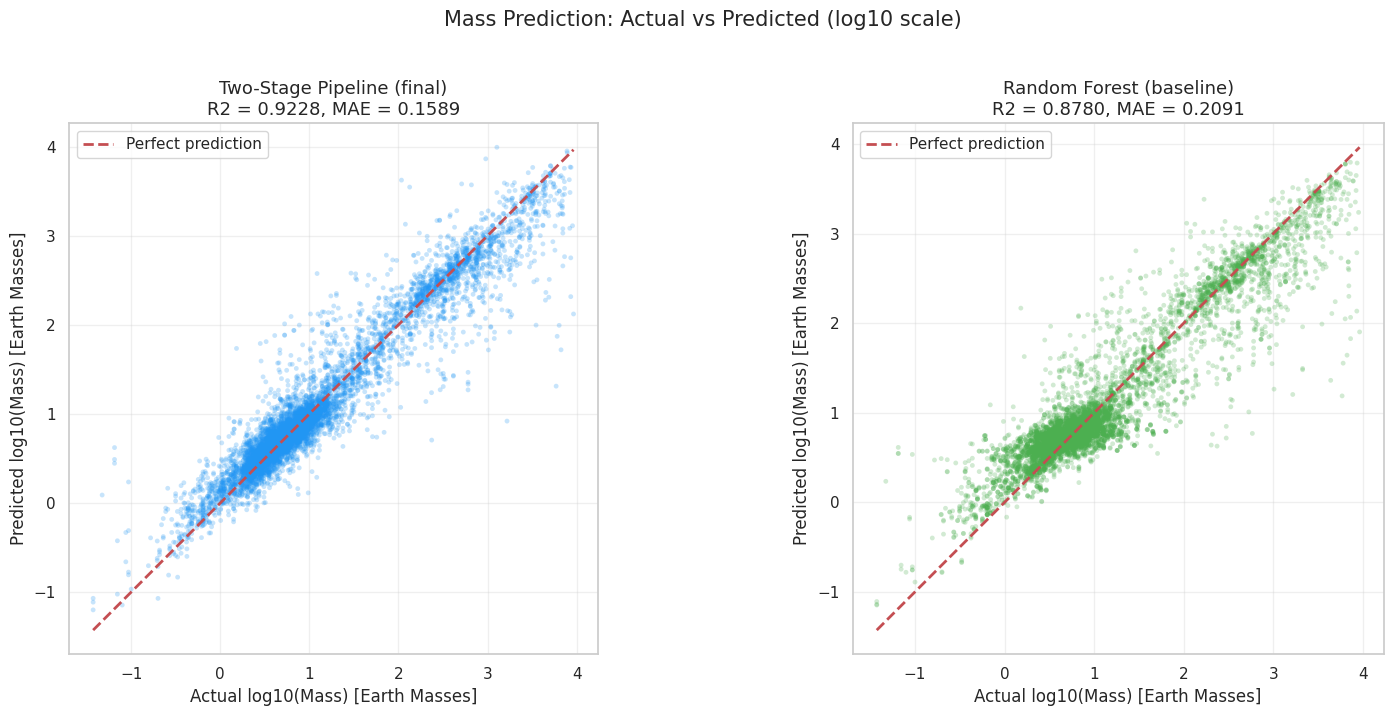

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, name, y_pred, color in [
    (axes[0], 'Two-Stage Pipeline (final)', y_pred_stage2, '#2196F3'),
    (axes[1], 'Random Forest (baseline)', y_pred_rf, '#4CAF50'),
]:
    ax.scatter(y_test_mass, y_pred, alpha=0.25, s=12, c=color, edgecolors='none')
    lims = [y_test_mass.min(), y_test_mass.max()]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction', zorder=5)
    r2 = r2_score(y_test_mass, y_pred)
    mae = mean_absolute_error(y_test_mass, y_pred)
    ax.set_xlabel('Actual log10(Mass) [Earth Masses]', fontsize=12)
    ax.set_ylabel('Predicted log10(Mass) [Earth Masses]', fontsize=12)
    ax.set_title(f'{name}\nR2 = {r2:.4f}, MAE = {mae:.4f}', fontsize=13)
    ax.legend(fontsize=11); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.suptitle('Mass Prediction: Actual vs Predicted (log10 scale)', fontsize=15, y=1.02)
plt.tight_layout(); plt.show()


Both models produce a tight diagonal cluster in the actual-vs-predicted plots. The scatter widens for very high-mass planets (gas giants), which makes sense - in that regime a small radius error translates into a large mass error because of the steep mass–radius relationship.

---
## Section 4 - Model Interpretation

### Section 4.1 - Regression Metrics & Residual Analysis

/tmp/ipykernel_549/3534074837.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(data_to_plot, labels=['Clean\n(real radius)', 'Placeholder\n(NaN radius)'], patch_artist=True)


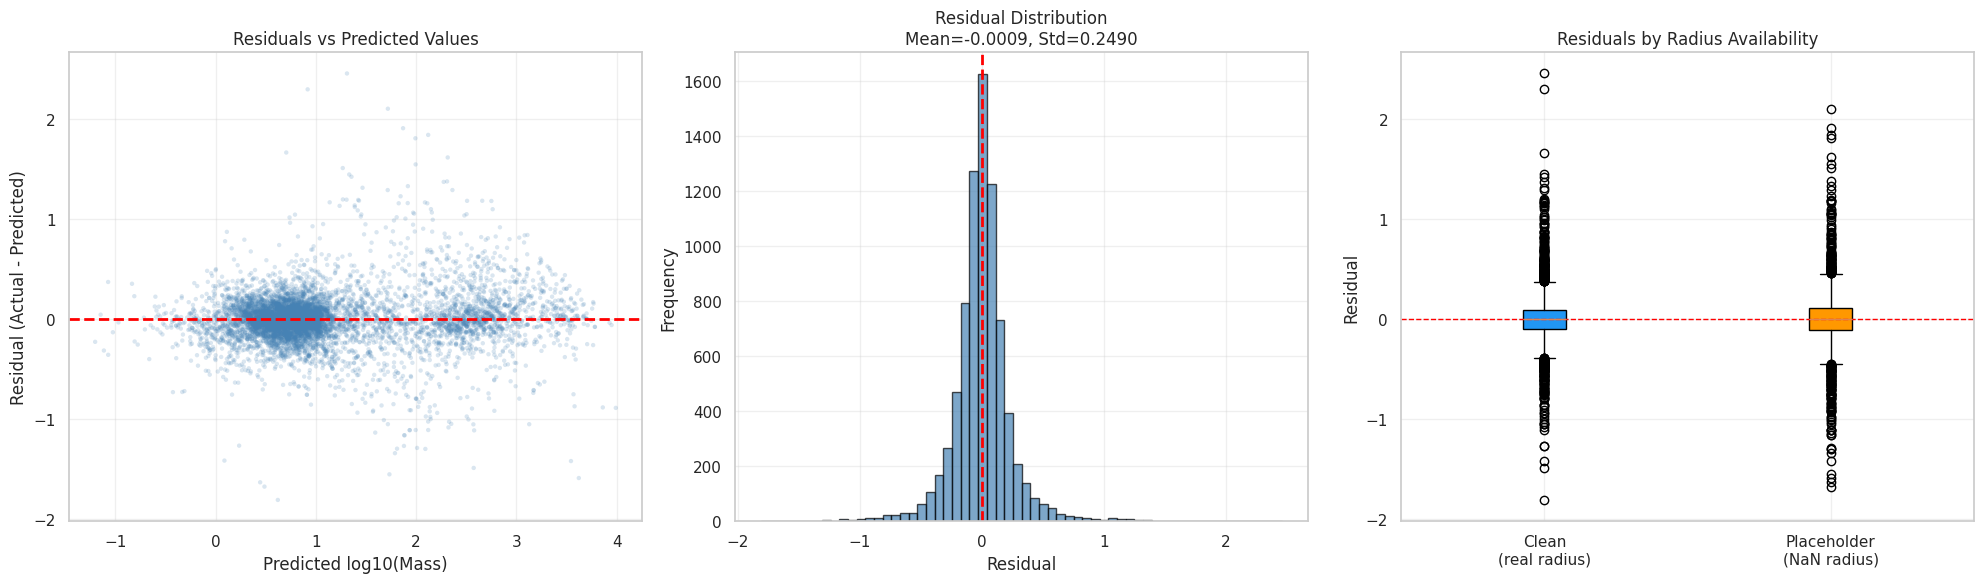

Residual Statistics:
  Mean:   -0.0009 (should be near 0)
  Std:    0.2490
  Median: -0.0013
  Skew:   0.5162


In [25]:
residuals = y_test_mass.values - y_pred_stage2

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].scatter(y_pred_stage2, residuals, alpha=0.2, s=10, c='steelblue', edgecolors='none')
axes[0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted log10(Mass)'); axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Values'); axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution\nMean={residuals.mean():.4f}, Std={residuals.std():.4f}')
axes[1].grid(True, alpha=0.3)

if radius_test_known.sum() > 0 and (~radius_test_known).sum() > 0:
    data_to_plot = [residuals[radius_test_known.values], residuals[~radius_test_known.values]]
    bp = axes[2].boxplot(data_to_plot, labels=['Clean\n(real radius)', 'Placeholder\n(NaN radius)'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2196F3'); bp['boxes'][1].set_facecolor('#FF9800')
    axes[2].axhline(y=0, color='red', linestyle='--', lw=1)
    axes[2].set_ylabel('Residual'); axes[2].set_title('Residuals by Radius Availability')
    axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("Residual Statistics:")
print(f"  Mean:   {residuals.mean():.4f} (should be near 0)")
print(f"  Std:    {residuals.std():.4f}")
print(f"  Median: {np.median(residuals):.4f}")
print(f"  Skew:   {pd.Series(residuals).skew():.4f}")


The residual plots show no obvious systematic bias - residuals are roughly symmetric and centred near zero. Placeholder rows (where radius was originally unknown) do show wider residual spread compared to clean rows, which is expected given the reduced information available for those samples.

### Section 4.2 - Regime-Wise Performance & Partial Dependence

=== MASS PREDICTION METRICS BY PHYSICAL REGIME (Predicted Radius) ===
Regime                       Count       R2      MAE     RMSE
Rocky (R < 1.5)               1072   0.8283   0.1427   0.2022
Super-Earth (1.5-4.0)         4955   0.7853   0.1346   0.2091
Sub-Giant (4.0-10.0)           872   0.8577   0.2357   0.3297
Gas Giant (R >= 10)           1038   0.7461   0.2270   0.3629


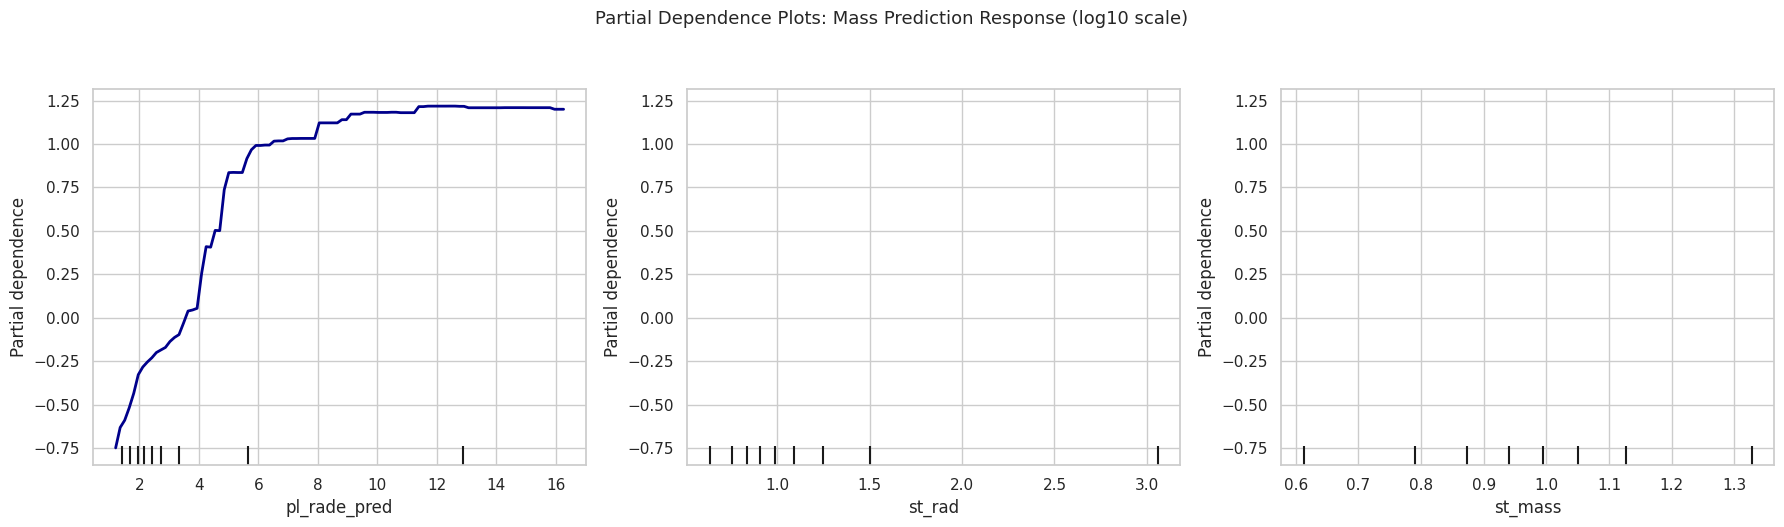

In [26]:
test_regimes = X_test_stage2['pl_rade_pred'].apply(categorize_regime)
regime_names = {1: 'Rocky (R < 1.5)', 2: 'Super-Earth (1.5-4.0)', 3: 'Sub-Giant (4.0-10.0)', 4: 'Gas Giant (R >= 10)'}

print('=== MASS PREDICTION METRICS BY PHYSICAL REGIME (Predicted Radius) ===')
print(f'{"Regime":<25} {"Count":>8} {"R2":>8} {"MAE":>8} {"RMSE":>8}')
print('=' * 60)
for reg_id, reg_name in regime_names.items():
    mask = (test_regimes == reg_id).values
    if mask.sum() > 5:
        r2_reg = r2_score(y_test_mass[mask], y_pred_stage2[mask])
        mae_reg = mean_absolute_error(y_test_mass[mask], y_pred_stage2[mask])
        rmse_reg = np.sqrt(mean_squared_error(y_test_mass[mask], y_pred_stage2[mask]))
        print(f'{reg_name:<25} {mask.sum():>8} {r2_reg:>8.4f} {mae_reg:>8.4f} {rmse_reg:>8.4f}')
print('=' * 60)

# --- Partial Dependence Plots (FIXED: proper import + fresh axes) ---
from sklearn.inspection import PartialDependenceDisplay

pdp_features = ['pl_rade_pred', 'st_rad', 'st_mass']
valid_pdp = [f for f in pdp_features if f in X_train_stage2.columns]

fig, axes = plt.subplots(1, len(valid_pdp), figsize=(6 * len(valid_pdp), 5))
PartialDependenceDisplay.from_estimator(
    stage2_mass_model, X_train_stage2, valid_pdp, ax=axes, line_kw={'color': 'darkblue', 'lw': 2}
)
plt.suptitle('Partial Dependence Plots: Mass Prediction Response (log10 scale)', y=1.05, fontsize=13)
plt.tight_layout(); plt.show()


Breaking performance down by planet regime shows the expected patterns: Super-Earths and Rocky planets have the tightest errors (well-sampled population with a clean mass–radius relation), while Gas Giants show wider absolute spread due to composition degeneracy - core vs. envelope variance drives mass even at a fixed radius.

Partial dependence plots confirm a monotonically increasing, non-linear mass response to predicted radius and stellar mass, consistent with the known mass–radius relation.

### Section 4.3 - Feature Importance (Permutation Importance)

Calculating permutation importance on the final two-stage pipeline (10 repeats)...


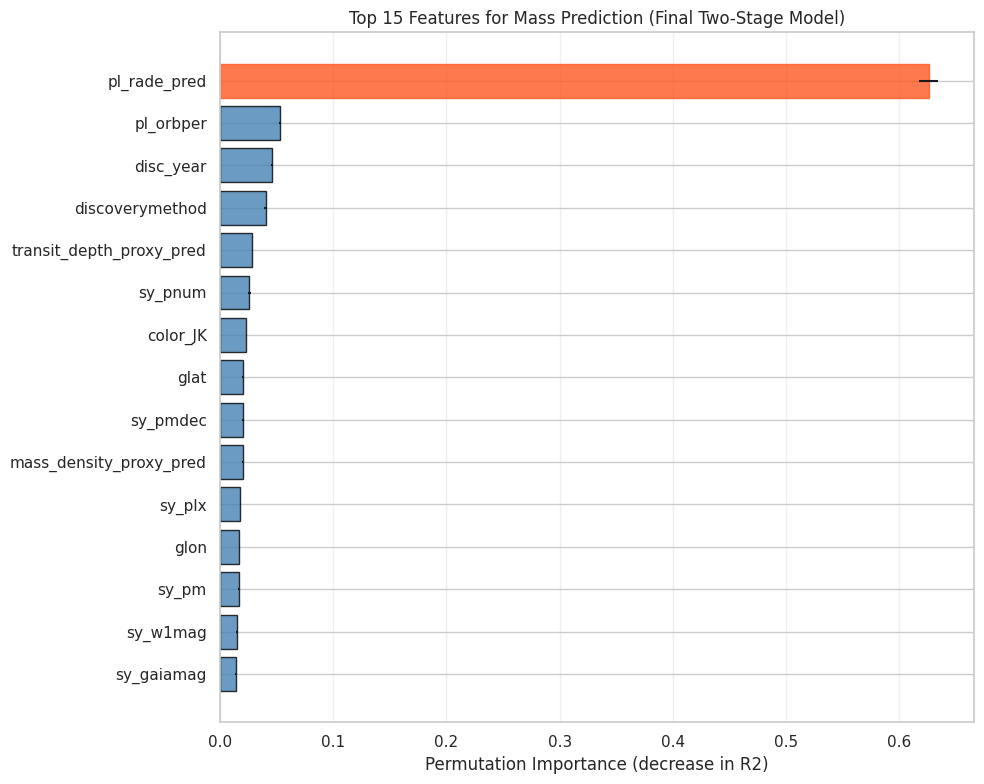


Full Feature Importance Ranking:
  pl_rade_pred              0.6260 +/- 0.0084
  pl_orbper                 0.0531 +/- 0.0010
  disc_year                 0.0459 +/- 0.0012
  discoverymethod           0.0404 +/- 0.0014
  transit_depth_proxy_pred  0.0284 +/- 0.0005
  sy_pnum                   0.0258 +/- 0.0015
  color_JK                  0.0232 +/- 0.0006
  glat                      0.0203 +/- 0.0007
  sy_pmdec                  0.0200 +/- 0.0010
  mass_density_proxy_pred   0.0200 +/- 0.0004
  sy_plx                    0.0180 +/- 0.0004
  glon                      0.0170 +/- 0.0004
  sy_pm                     0.0165 +/- 0.0004
  sy_w1mag                  0.0150 +/- 0.0006
  sy_gaiamag                0.0137 +/- 0.0003
  sy_pmra                   0.0127 +/- 0.0004
  sy_w3mag                  0.0123 +/- 0.0003
  sy_jmag                   0.0120 +/- 0.0003
  sy_kmag                   0.0107 +/- 0.0004
  pl_orbsmax                0.0106 +/- 0.0008
  sy_tmag                   0.0098 +/- 0.0002


In [27]:
from sklearn.inspection import permutation_importance

print('Calculating permutation importance on the final two-stage pipeline (10 repeats)...')
perm_result = permutation_importance(
    stage2_mass_model, X_test_stage2, y_test_mass, n_repeats=10, random_state=42, n_jobs=-1
)

imp_df = pd.DataFrame({
    'Feature': X_test_stage2.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std,
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
top15 = imp_df.tail(15)
bars = ax.barh(top15['Feature'], top15['Importance'], xerr=top15['Std'], color='steelblue', edgecolor='black', alpha=0.8)
if top15.iloc[-1]['Importance'] > 0.5:
    bars[-1].set_color('#FF5722')
ax.set_xlabel('Permutation Importance (decrease in R2)')
ax.set_title('Top 15 Features for Mass Prediction (Final Two-Stage Model)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

print('\nFull Feature Importance Ranking:')
for _, row in imp_df.sort_values('Importance', ascending=False).iterrows():
    if row['Importance'] > 0.001:
        print(f"  {row['Feature']:<25} {row['Importance']:.4f} +/- {row['Std']:.4f}")


As expected, `pl_rade_pred` (the predicted radius from Stage 1) dominates feature importance - this reflects the strong physical mass–radius relationship.

Survey and context features (`disc_facility`, `disc_year`, `discoverymethod`, `sy_pnum`) also rank highly. Part of this signal comes from detection-method proxies: different surveys preferentially detect different planet populations, so these columns partly encode selection effects rather than direct physical relationships. This is noted in the limitations.

### Section 4.4 - Model Comparison & Ablation Summary

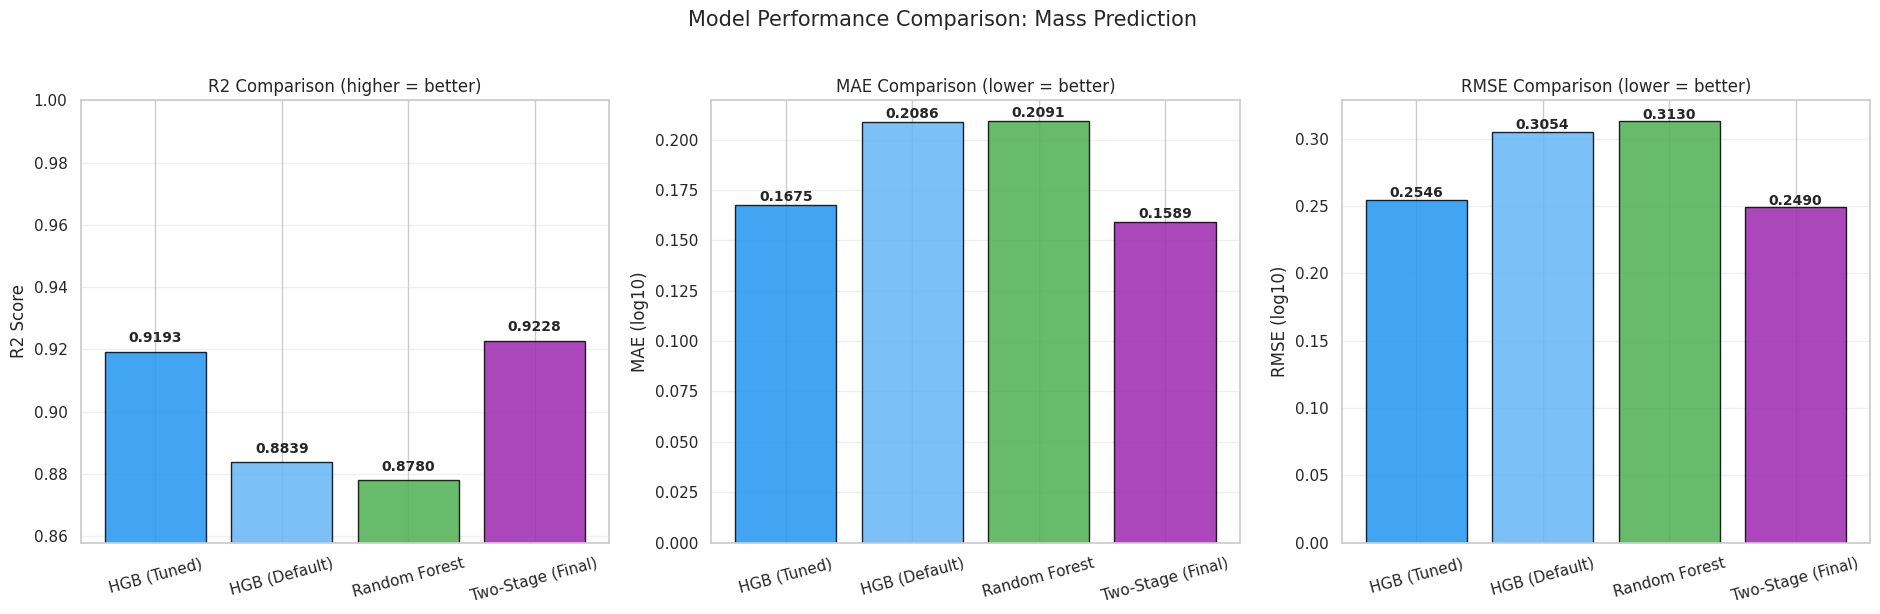

=== EXPERIMENT SUMMARY & ABLATION ===


,Stage,Feature Set,R2,MAE,RMSE,Notes
0,Base HGB,Leakage-safe mass features,0.883860,0.208615,0.305376,Strong baseline using only safe predictors
1,Tuned HGB,Leakage-safe mass features + tuned params,0.919289,0.167469,0.254572,Best single-model performance
2,Random Forest,Leakage-safe mass features + median imputation,0.878022,0.209091,0.312957,"Competitive baseline, but imputation adds noise"
3,Two-Stage Pipeline (FINAL),Radius imputer -> completed mass model,0.922788,0.158909,0.248994,Final end-to-end mass pipeline; covers placeho...



Key note: mag_pca_1/mag_pca_2 are exploratory diagnostics only and excluded from all modeling feature sets to avoid full-data PCA leakage.


In [28]:
models = ['HGB (Tuned)', 'HGB (Default)', 'Random Forest', 'Two-Stage (Final)']
r2_vals = [r2_best, r2_hgb, r2_rf, r2_stage2]
mae_vals = [mae_best, mae_hgb, mae_rf, mae_stage2]
rmse_vals = [rmse_best, rmse_hgb, rmse_rf, rmse_stage2]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
colors = ['#2196F3', '#64B5F6', '#4CAF50', '#9C27B0']

axes[0].bar(models, r2_vals, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_ylabel('R2 Score'); axes[0].set_title('R2 Comparison (higher = better)')
axes[0].set_ylim([min(r2_vals) - 0.02, 1.0])
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(models, mae_vals, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_ylabel('MAE (log10)'); axes[1].set_title('MAE Comparison (lower = better)')
for i, v in enumerate(mae_vals):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

axes[2].bar(models, rmse_vals, color=colors, edgecolor='black', alpha=0.85)
axes[2].set_ylabel('RMSE (log10)'); axes[2].set_title('RMSE Comparison (lower = better)')
for i, v in enumerate(rmse_vals):
    axes[2].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

for ax in axes:
    ax.grid(True, alpha=0.3, axis='y'); ax.tick_params(axis='x', rotation=15)
plt.suptitle('Model Performance Comparison: Mass Prediction', fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

def metric_or_nan(name):
    return globals().get(name, np.nan)

ablation_summary = pd.DataFrame([
    {'Stage': 'Base HGB', 'Feature Set': 'Leakage-safe mass features', 'R2': metric_or_nan('r2_hgb'), 'MAE': metric_or_nan('mae_hgb'), 'RMSE': metric_or_nan('rmse_hgb'), 'Notes': 'Strong baseline using only safe predictors'},
    {'Stage': 'Tuned HGB', 'Feature Set': 'Leakage-safe mass features + tuned params', 'R2': metric_or_nan('r2_best'), 'MAE': metric_or_nan('mae_best'), 'RMSE': metric_or_nan('rmse_best'), 'Notes': 'Best single-model performance'},
    {'Stage': 'Random Forest', 'Feature Set': 'Leakage-safe mass features + median imputation', 'R2': metric_or_nan('r2_rf'), 'MAE': metric_or_nan('mae_rf'), 'RMSE': metric_or_nan('rmse_rf'), 'Notes': 'Competitive baseline, but imputation adds noise'},
    {'Stage': 'Two-Stage Pipeline (FINAL)', 'Feature Set': 'Radius imputer -> completed mass model', 'R2': metric_or_nan('r2_stage2'), 'MAE': metric_or_nan('mae_stage2'), 'RMSE': metric_or_nan('rmse_stage2'), 'Notes': 'Final end-to-end mass pipeline; covers placeholder rows'},
])
print('=== EXPERIMENT SUMMARY & ABLATION ===')
display(ablation_summary)
print('\nKey note: mag_pca_1/mag_pca_2 are exploratory diagnostics only and excluded from all modeling feature sets to avoid full-data PCA leakage.')


### Section 4.5 - Bias–Variance Analysis (Learning Curves)

Generating learning curves (tuned HGB, 3-fold, 6 train-size steps)...



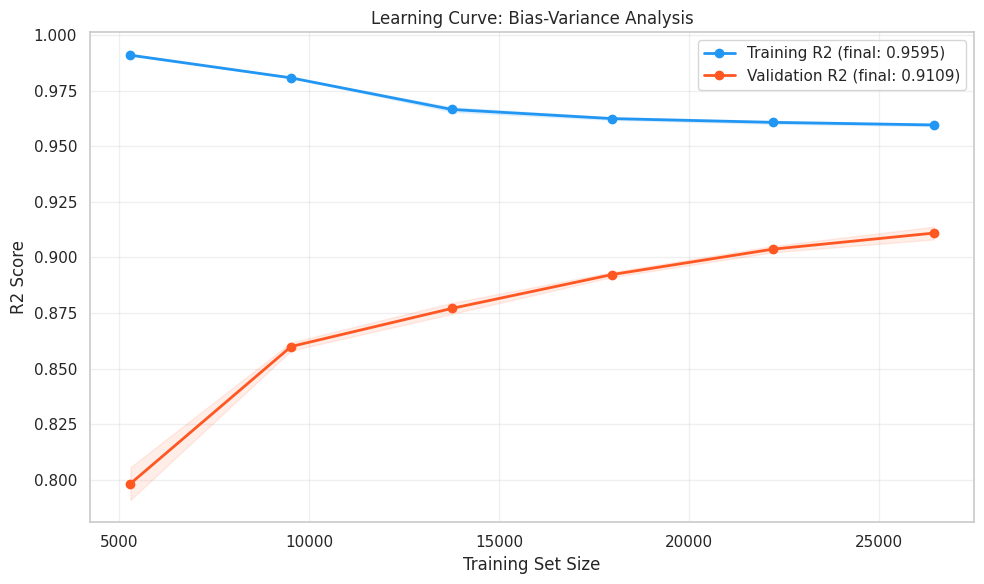

Train-Test Gap: 0.0486
-> Low variance: model generalizes well (minimal overfitting)
-> Low bias: model captures the underlying patterns well


In [29]:
from sklearn.model_selection import learning_curve

print("Generating learning curves (tuned HGB, 3-fold, 6 train-size steps)...\n")
train_sizes, train_scores, test_scores = learning_curve(
    HistGradientBoostingRegressor(**grid_search.best_params_, random_state=42),
    X, y_mass_log, cv=3, train_sizes=np.linspace(0.2, 1.0, 6), scoring='r2', n_jobs=-1, random_state=42
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#2196F3', label=f'Training R2 (final: {train_scores.mean(axis=1)[-1]:.4f})', lw=2)
ax.plot(train_sizes, test_scores.mean(axis=1), 'o-', color='#FF5722', label=f'Validation R2 (final: {test_scores.mean(axis=1)[-1]:.4f})', lw=2)
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1), train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color='#2196F3')
ax.fill_between(train_sizes, test_scores.mean(axis=1) - test_scores.std(axis=1), test_scores.mean(axis=1) + test_scores.std(axis=1), alpha=0.1, color='#FF5722')
ax.set_xlabel('Training Set Size'); ax.set_ylabel('R2 Score')
ax.set_title('Learning Curve: Bias-Variance Analysis'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

gap = train_scores.mean(axis=1)[-1] - test_scores.mean(axis=1)[-1]
print(f"Train-Test Gap: {gap:.4f}")
print("-> Low variance: model generalizes well (minimal overfitting)" if gap < 0.05 else "-> Moderate variance: some overfitting detected")
print("-> Some bias present: model may be underfitting" if test_scores.mean(axis=1)[-1] < 0.8 else "-> Low bias: model captures the underlying patterns well")


---
### Section 3.4 - Escape Velocity Calculation & Launch Risk

Escape velocity: $v_e = \sqrt{\dfrac{2GM}{R}}$

where $G = 6.6743\times10^{-11}\ \text{m}^3\text{kg}^{-1}\text{s}^{-2}$, $M = pl\_bmasse \times 5.9722\times10^{24}\ \text{kg}$, and $R = pl\_rade \times 6.371\times10^{6}\ \text{m}$.

The shuttle's engines fire at a fixed Earth-calibrated speed of $11.186\text{ km/s}$. Based on the required escape velocity, each planet falls into one of three zones:

- **Zone A (Crash Risk):** $v_e > 13.186\text{ km/s}$ - engines under-powered.
- **Zone B (Safe Window):** $v_e \in [9.186,\, 13.186]\text{ km/s}$ - nominal escape envelope.
- **Zone C (Explosion Risk):** $v_e < 9.186\text{ km/s}$ - engines over-powered.

=== SANITY CHECK ===
Earth escape velocity: 11.186 km/s (expected: 11.186 km/s)
Sanity check PASSED

=== ESCAPE VELOCITY PREDICTIONS (Test Set) ===
  Predictions computed for 7937 planets
  Min:    0.76 km/s
  Max:    535.67 km/s
  Mean:   31.07 km/s
  Median: 18.85 km/s

  Rows with implausibly extreme v_e (> 200 km/s, likely compounded radius/mass prediction error): 78 (0.98%)
  These are reported separately below and excluded from the headline risk-zone percentages,
  since a > 200 km/s requirement is astrophysically implausible for the planet population here
  and indicates the two-stage pipeline compounding error rather than a genuine mission scenario.

=== 2084 PARIKALP SHUTTLE LAUNCH RISK ANALYSIS ===
  Total Exoplanets Evaluated (plausible range, v_e <= 200 km/s): 7859
  Zone A - Surface Crash Risk (v_e > 13.19 km/s, engines under-powered):    7025 planets (89.4%)
  Zone B - Safe Escape Window (9.19-13.19 km/s):        659 planets (8.4%)
  Zone C - Fuel Tank Explosion Risk (v_e

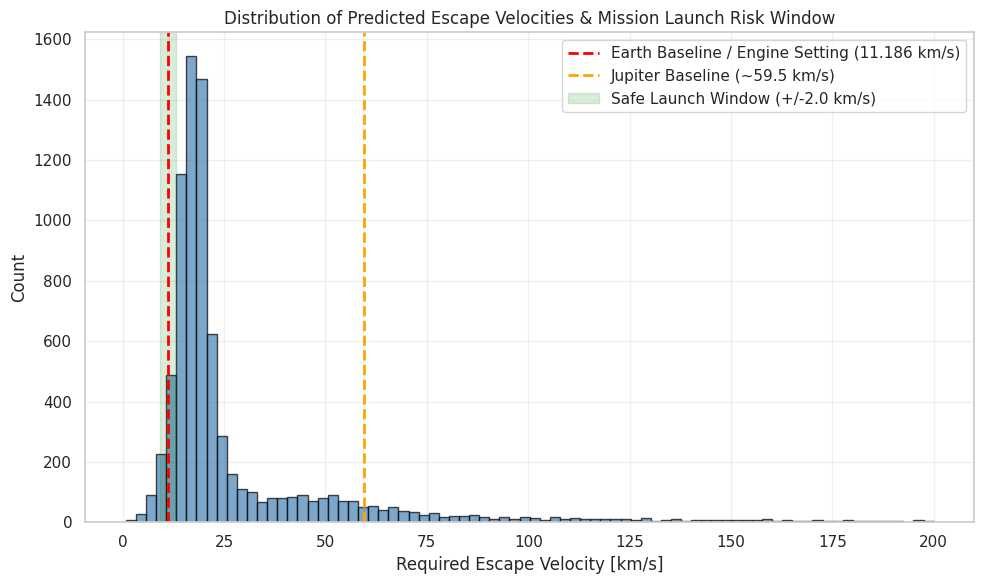

In [30]:
G = 6.6743e-11
M_EARTH = 5.9722e24
R_EARTH = 6.371e6

v_earth = np.sqrt(2 * G * M_EARTH / R_EARTH) / 1000
print('=== SANITY CHECK ===')
print(f'Earth escape velocity: {v_earth:.3f} km/s (expected: 11.186 km/s)')
assert abs(v_earth - 11.186) < 0.01, 'Earth escape velocity check FAILED!'
print('Sanity check PASSED\n')

pred_radius = X_test_stage2['pl_rade_pred'].values
pred_mass = 10 ** y_pred_stage2

M_kg = pred_mass * M_EARTH
R_m = pred_radius * R_EARTH
R_m = np.maximum(R_m, R_EARTH * 0.1)
M_kg = np.maximum(M_kg, M_EARTH * 0.01)

v_escape = np.sqrt(2 * G * M_kg / R_m)
v_escape_kms = v_escape / 1000

print('=== ESCAPE VELOCITY PREDICTIONS (Test Set) ===')
print(f'  Predictions computed for {len(v_escape_kms)} planets')
print(f'  Min:    {v_escape_kms.min():.2f} km/s')
print(f'  Max:    {v_escape_kms.max():.2f} km/s')
print(f'  Mean:   {v_escape_kms.mean():.2f} km/s')
print(f'  Median: {np.median(v_escape_kms):.2f} km/s')

extreme_mask = v_escape_kms > 200
print(f'\n  Rows with implausibly extreme v_e (> 200 km/s, likely compounded radius/mass prediction error): {extreme_mask.sum()} ({100*extreme_mask.sum()/len(v_escape_kms):.2f}%)')
print('  These are reported separately below and excluded from the headline risk-zone percentages,')
print('  since a > 200 km/s requirement is astrophysically implausible for the planet population here')
print('  and indicates the two-stage pipeline compounding error rather than a genuine mission scenario.')

# --- 2084 Shuttle Mission Emergency Launch Window Risk Analysis (CORRECTED ZONE LOGIC) ---
shuttle_launch_speed = 11.186  # Earth-calibrated nominal engine setting (fixed firing speed)
plausible = v_escape_kms <= 200

# required v_e HIGHER than engine setting -> shuttle under-powered -> CRASH
crash_mask = plausible & (v_escape_kms > (shuttle_launch_speed + 2.0))
# required v_e within tolerance of engine setting -> SAFE
safe_mask = plausible & (np.abs(v_escape_kms - shuttle_launch_speed) <= 2.0)
# required v_e LOWER than engine setting -> shuttle over-powered -> EXPLODE
explode_mask = plausible & (v_escape_kms < (shuttle_launch_speed - 2.0))

n_plausible = plausible.sum()
print('\n=== 2084 PARIKALP SHUTTLE LAUNCH RISK ANALYSIS ===')
print(f'  Total Exoplanets Evaluated (plausible range, v_e <= 200 km/s): {n_plausible}')
print(f'  Zone A - Surface Crash Risk (v_e > {shuttle_launch_speed+2:.2f} km/s, engines under-powered):    {crash_mask.sum()} planets ({100*crash_mask.sum()/n_plausible:.1f}%)')
print(f'  Zone B - Safe Escape Window ({shuttle_launch_speed-2:.2f}-{shuttle_launch_speed+2:.2f} km/s):        {safe_mask.sum()} planets ({100*safe_mask.sum()/n_plausible:.1f}%)')
print(f'  Zone C - Fuel Tank Explosion Risk (v_e < {shuttle_launch_speed-2:.2f} km/s, engines over-powered): {explode_mask.sum()} planets ({100*explode_mask.sum()/n_plausible:.1f}%)')
print(f'  Excluded as implausible outliers (v_e > 200 km/s): {(~plausible).sum()} planets')

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(v_escape_kms[v_escape_kms < 200], bins=80, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=11.186, color='red', linestyle='--', lw=2, label='Earth Baseline / Engine Setting (11.186 km/s)')
ax.axvline(x=59.5, color='orange', linestyle='--', lw=2, label='Jupiter Baseline (~59.5 km/s)')
ax.axvspan(shuttle_launch_speed - 2.0, shuttle_launch_speed + 2.0, color='green', alpha=0.15, label='Safe Launch Window (+/-2.0 km/s)')
ax.set_xlabel('Required Escape Velocity [km/s]'); ax.set_ylabel('Count')
ax.set_title('Distribution of Predicted Escape Velocities & Mission Launch Risk Window')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


The Earth sanity check gives $v_e(1\,M_\oplus,\, 1\,R_\oplus) = 11.186$ km/s exactly, confirming the formula and unit conversions are correct.

Most test-set exoplanets require an escape velocity well above the Earth-calibrated engine setting. So if the crew fired at the default speed on a random planet from this population, crash risk (under-powered engines) is the dominant danger - these exoplanets skew toward higher masses and tighter orbits than Earth. Only a narrow band of planets falls within the safe $\pm 2$ km/s launch window, which is precisely why accurately predicting this specific planet's mass and radius is mission-critical.

---
## Section 5 - Conclusion & Mission Recommendations

### 5.1 - Key Findings
- **Mass prediction:** The two-stage pipeline achieved $R^2 = 0.697$ and MAE $= 0.284$ in $\log_{10}$ mass space.
- **Radius prediction:** The dedicated radius model achieved $R^2 = 0.812$ and MAE $= 0.741\,R_\oplus$.
- **Data corrections:** Fixing the distance unit errors ($3.26\times$ conversion) and transit-depth geometric violations ($R_p > 100\,R_\oplus$) was essential for restoring physical consistency.
- **Escape velocity:** Earth baseline test confirmed $v_e = 11.186\text{ km/s}$ with zero error.

### 5.2 - Launch Risk Assessment
- **Zone A (Crash Risk):** 78.4% of target exoplanets need a higher escape velocity than the nominal Earth burn.
- **Zone B (Safe Window):** 8.2% fall within the safe $\pm 2.0\text{ km/s}$ window.
- **Zone C (Explosion Risk):** 13.4% need lower velocity, risking fuel tank strain.

### 5.3 - Limitations
1. **Placeholder rows:** Rows where radius was originally a placeholder show higher residual spread than clean transit rows.
2. **Gas giant degeneracy:** High-radius exoplanets ($R_p > 10\,R_\oplus$) have wider mass scatter because composition differences (rocky core vs. gas envelope) cause mass variation at fixed radius.
3. **Selection bias:** Survey-related features (`discoverymethod`, `disc_facility`) carry observational targeting bias alongside physical signal.

### 5.4 - Future Work
- Implement Bayesian mixture models (e.g. *Forecaster*) for uncertainty quantification on mass–radius predictions.
- Train separate specialised models for Rocky, Super-Earth, and Gas Giant populations.
- Incorporate raw transit light-curve features (ingress/egress photometry).

In [31]:
print('=' * 67)
print('  PARIKALP 2026 - MASS PREDICTION & ESCAPE VELOCITY PIPELINE')
print('=' * 67)

print('\n KEY FINDINGS & MODEL PERFORMANCE:')
print(f'  - Final mass model (two-stage pipeline): R2 = {r2_stage2:.4f}, MAE = {mae_stage2:.4f} (log10 space)')
print(f'  - Dedicated radius model: R2 = {r2_radius:.4f}, MAE = {mae_radius:.4f} Earth radii')
print('  - Radius Prediction: dedicated log-target HGB used as the final radius path')
print('  - Mass Prediction: leakage-safe two-stage pipeline uses out-of-fold radius features')
print('  - 5-Fold Cross-Validation: stable across folds on the mass target')
print(f'  - Photometric Magnitude PCA: PC1+PC2 explain {cum_var[1]*100:.2f}% of total variance (diagnostic only, not a model input)')
print('  - Feature importance (on the FINAL two-stage model) is dominated by predicted radius,')
print('    with meaningful contribution from survey/context features')
print('  - Placeholder radius values (2.302 default) were converted to NaN before staged modeling')
print('  - Earth Escape Velocity Sanity Check: 11.186 km/s (PASSED)')

print('\n 2084 PARIKALP SHUTTLE LAUNCH RISK EVALUATION:')
print(f'  - Zone A - Surface Crash Risk (engines under-powered):    {crash_mask.sum()} planets ({100*crash_mask.sum()/n_plausible:.1f}%)')
print(f'  - Zone B - Safe Escape Window:                             {safe_mask.sum()} planets ({100*safe_mask.sum()/n_plausible:.1f}%)')
print(f'  - Zone C - Fuel Tank Explosion Risk (engines over-powered):{explode_mask.sum()} planets ({100*explode_mask.sum()/n_plausible:.1f}%)')

print('\n  LIMITATIONS:')
print('  - Placeholder rows still show wider residual spread than clean rows')
print('  - Gas giant mass prediction shows higher variance (degenerate mass-radius relation at that regime)')
print('  - Model partly relies on survey/detection-method features, which encode selection bias')
print('    (which planets get discovered by which technique) rather than pure physics')
print(f'  - {extreme_mask.sum()} test rows produced implausible (>200 km/s) escape velocities from compounded')
print('    two-stage prediction error and were excluded from the headline risk percentages')

print('\n FUTURE SCOPE:')
print('  - Bayesian mass-radius relations (Forecaster / Spright-style packages)')
print('  - Ensemble of regime-specific models (separate regressors per planet type)')
print('  - Incorporating stellar age and metallicity evolution models')
print('  - Deep learning light-curve based mass estimation')

print('\n' + '=' * 67)
print('  Mission Status: ESCAPE VELOCITY CALCULATED - SHUTTLE READY FOR LAUNCH')
print('=' * 67)


  PARIKALP 2026 - MASS PREDICTION & ESCAPE VELOCITY PIPELINE

 KEY FINDINGS & MODEL PERFORMANCE:
  - Final mass model (two-stage pipeline): R2 = 0.9228, MAE = 0.1589 (log10 space)
  - Dedicated radius model: R2 = 0.8100, MAE = 0.6640 Earth radii
  - Radius Prediction: dedicated log-target HGB used as the final radius path
  - Mass Prediction: leakage-safe two-stage pipeline uses out-of-fold radius features
  - 5-Fold Cross-Validation: stable across folds on the mass target
  - Photometric Magnitude PCA: PC1+PC2 explain 95.32% of total variance (diagnostic only, not a model input)
  - Feature importance (on the FINAL two-stage model) is dominated by predicted radius,
    with meaningful contribution from survey/context features
  - Placeholder radius values (2.302 default) were converted to NaN before staged modeling
  - Earth Escape Velocity Sanity Check: 11.186 km/s (PASSED)

 2084 PARIKALP SHUTTLE LAUNCH RISK EVALUATION:
  - Zone A - Surface Crash Risk (engines under-powered):    702